In [ ]:
import folium
import geojson
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import plotly.express as px
import plotly.graph_objects as go

from folium import plugins
from folium.plugins import HeatMap
from matplotlib.ticker import FuncFormatter, MultipleLocator
from scipy import stats

In [ ]:
df_rent = pd.read_csv('data/mean_rents_all_years.csv')
df_rent['Borough'] = df_rent['Borough'].str.upper()
df_rent.head()

In [ ]:
# df_rent[df_rent['Borough']=='STATEN ISLAND']

In [ ]:
# import glob
# import pandas as pd

# # Function to load and combine all boroughs for a given year
# def load_ethnicity_year(year):
#     files = glob.glob(f'data/ethnicity_{year}_*.csv')
#     dfs = []
    
#     for file in files:
#         # Extract borough name from filename
#         borough = file.split('_')[-1].replace('.csv', '')
        
#         # Read CSV
#         df = pd.read_csv(file, skiprows=5)
        
#         # Keep only the columns you need
#         df = df[['Unnamed: 0', 'Number.1', 'Percent.1']].copy()
        
#         # Rename columns and add borough
#         df.columns = ['ethnicity', 'number', 'percent']
#         if borough == 'island':
#             df['borough'] = 'STATEN ISLAND'
#         else:
#             df['borough'] = borough.upper()
        
#         dfs.append(df)
    
#     # Combine all boroughs
#     result = pd.concat(dfs, ignore_index=True)
#     return result

# # Load both years
# ethnicity_2010 = load_ethnicity_year(2010)
# ethnicity_2020 = load_ethnicity_year(2020)

# print(ethnicity_2010.head(10))
# print(ethnicity_2020.head(10))

In [ ]:
import requests
import pandas as pd

def get_race_data(year):
    url = f"https://api.census.gov/data/{year}/acs/acs5"
    params = {
        "get": "NAME,B02001_001E,B02001_002E,B02001_003E,B02001_004E,B02001_005E,B02001_006E,B02001_007E",
        "for": "county:*",
        "in": "state:36"  # New York State
    }
    response = requests.get(url, params=params).json()
    df = pd.DataFrame(response[1:], columns=response[0])
    return df

race_2010 = get_race_data(2010)
race_2020 = get_race_data(2020)


In [ ]:
county_to_borough = {
    "Bronx County, New York": "BRONX",
    "Kings County, New York": "BROOKLYN",
    "New York County, New York": "MANHATTAN",
    "Queens County, New York": "QUEENS",
    "Richmond County, New York": "STATEN ISLAND"
}


In [ ]:
def clean_race(df):
    df['Borough'] = df['NAME'].map(county_to_borough)
    df = df[df['Borough'].notna()].copy()

    race_cols = [
        "B02001_001E","B02001_002E","B02001_003E",
        "B02001_004E","B02001_005E","B02001_006E","B02001_007E"
    ]

    for col in race_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    return df

race_2010 = clean_race(race_2010)
race_2020 = clean_race(race_2020)


In [ ]:
race_cols = [
    "B02001_001E",  # total
    "B02001_002E",  # white
    "B02001_003E",  # black
    "B02001_004E",  # native
    "B02001_005E",  # asian
    "B02001_006E",  # pacific islander
    "B02001_007E"   # some other race
]

for col in race_cols:
    race_2010[col] = pd.to_numeric(race_2010[col], errors="coerce")
    race_2020[col] = pd.to_numeric(race_2020[col], errors="coerce")


In [ ]:
race_2010.head()

In [ ]:
def clean_ethnicity(df):
    df = df[df['number'].notna()].copy()
    
    # Debug: check what type number is
    print(f"Number dtype before: {df['number'].dtype}")
    print(f"Sample numbers: {df['number'].head()}")
    
    # Convert number column - remove commas first if they're strings
    df['number'] = df['number'].astype(str).str.replace(',', '')
    df['number'] = pd.to_numeric(df['number'], errors='coerce')
    
    print(f"Number dtype after: {df['number'].dtype}")
    print(f"Sample numbers after conversion: {df['number'].head()}")
    
    # Clean ethnicity and Borough names
    df['ethnicity'] = df['ethnicity'].str.strip()
    df['Borough'] = df['Borough'].str.strip().str.upper()
    
    # Get total population for each Borough
    total_pop = df[df['ethnicity'] == 'Total Population'].set_index('Borough')['number']
    print(f"\nTotal pop by Borough:\n{total_pop}")
    
    # Calculate percentage from total population
    df['percent_calc'] = df.apply(
        lambda row: (row['number'] / total_pop.get(row['Borough'])) * 100 
        if row['Borough'] in total_pop.index and pd.notna(row['number']) 
        else np.nan,
        axis=1
    )
    
    return df

In [ ]:
race_2010 = race_2010.rename(columns={
    "B02001_001E": "total_2010",
    "B02001_002E": "white_2010",
    "B02001_003E": "black_2010",
    "B02001_004E": "native_american_2010",
    "B02001_005E": "asian_2010",
    "B02001_006E": "pacific_islander_2010",
    "B02001_007E": "other_2010"
})

race_2020 = race_2020.rename(columns={
    "B02001_001E": "total_2020",
    "B02001_002E": "white_2020",
    "B02001_003E": "black_2020",
    "B02001_004E": "native_american_2020",
    "B02001_005E": "asian_2020",
    "B02001_006E": "pacific_islander_2020",
    "B02001_007E": "other_2020"
})


In [ ]:
# list(ethnicity_2010['ethnicity'].unique())

In [ ]:
# eth10 = clean_ethnicity(ethnicity_2010)
# eth20 = clean_ethnicity(ethnicity_2020)


In [ ]:
race = race_2010.merge(race_2020, on="Borough", suffixes=("_2010", "_2020"))

In [ ]:
race.head()

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import pearsonr

# ---------------------------------------------------------
# 0. Borough colors (edit these hex codes anytime)
# ---------------------------------------------------------

borough_colors = {
    "MANHATTAN": "#1f77b4",
    "BROOKLYN": "#ff7f0e",
    "QUEENS": "#2ca02c",
    "BRONX": "#d62728",
    "STATEN ISLAND": "#9467bd"
}

# ---------------------------------------------------------
# 1. Your existing rent pipeline (unchanged)
# ---------------------------------------------------------

rent_cols_2010 = [c for c in df_rent.columns if c.startswith("2010")]
rent_cols_2020 = [c for c in df_rent.columns if c.startswith("2020")]

df_rent['rent_2010_mean'] = df_rent[rent_cols_2010].mean(axis=1)
df_rent['rent_2020_mean'] = df_rent[rent_cols_2020].mean(axis=1)

rent_2010 = df_rent[['Borough', 'apartmentType', 'rent_2010_mean']].copy()
rent_2010['year'] = "2010"
rent_2010 = rent_2010.rename(columns={'rent_2010_mean': 'rent'})

rent_2020 = df_rent[['Borough', 'apartmentType', 'rent_2020_mean']].copy()
rent_2020['year'] = "2020"
rent_2020 = rent_2020.rename(columns={'rent_2020_mean': 'rent'})

rent_long = pd.concat([rent_2010, rent_2020], ignore_index=True)

# ---------------------------------------------------------
# 2. Compute race shares (distribution)
# ---------------------------------------------------------

for group in ["white", "black", "asian", "native_american", "pacific_islander", "other"]:
    race[f"{group}_share_2010"] = race[f"{group}_2010"] / race["total_2010"]
    race[f"{group}_share_2020"] = race[f"{group}_2020"] / race["total_2020"]

# ---------------------------------------------------------
# 3. Reshape race shares into long format
# ---------------------------------------------------------

race_long = race.melt(
    id_vars=["Borough"],
    value_vars=[
        "white_share_2010", "black_share_2010", "asian_share_2010",
        "native_american_share_2010", "pacific_islander_share_2010", "other_share_2010",
        "white_share_2020", "black_share_2020", "asian_share_2020",
        "native_american_share_2020", "pacific_islander_share_2020", "other_share_2020"
    ],
    var_name="group_year",
    value_name="share"
)

race_long["group"] = race_long["group_year"].str.extract(r"(.*)_share")[0]
race_long["year"] = race_long["group_year"].str.extract(r"(\d{4})")[0]

# ---------------------------------------------------------
# 4. Merge race shares with rent_long
# ---------------------------------------------------------

df_plot = race_long.merge(rent_long, on=["Borough", "year"], how="left")

# ---------------------------------------------------------
# 5. Build interactive Plotly figure with apartment type dropdown
# ---------------------------------------------------------

apt_types = sorted(df_plot["apartmentType"].unique())
groups = df_plot["group"].unique()
years = ["2010", "2020"]

year_shapes = {"2010": "circle", "2020": "square"}

cols = 2
rows = int(np.ceil(len(groups) / cols))

fig = make_subplots(
    rows=rows,
    cols=cols,
    subplot_titles=groups,
    horizontal_spacing=0.12,
    vertical_spacing=0.12
)

# Visibility masks for apartment types
visibility_masks = {apt: [] for apt in apt_types}

row = 1
col = 1

for group in groups:
    for apt in apt_types:
        for year in years:
            sub = df_plot[
                (df_plot["group"] == group) &
                (df_plot["apartmentType"] == apt) &
                (df_plot["year"] == year)
            ]

            # Scatter
            scatter = go.Scatter(
                x=sub["share"],
                y=sub["rent"],
                mode="markers",
                marker=dict(
                    size=12,
                    symbol=year_shapes[year],
                    color=[borough_colors[b] for b in sub["Borough"]]
                ),
                name=f"{group} — {year}",
                text=sub["Borough"],
                hovertemplate="<b>%{text}</b><br>Share: %{x:.2%}<br>Rent: %{y}<br>"
            )
            fig.add_trace(scatter, row=row, col=col)
            
            # Add to visibility mask for each apartment type
            for a in apt_types:
                visibility_masks[a].append(a == apt)

    col += 1
    if col > cols:
        col = 1
        row += 1

# ---------------------------------------------------------
# 6. Dropdown menu (apartment type)
# ---------------------------------------------------------

buttons = []
for apt in apt_types:
    buttons.append(
        dict(
            label=apt,
            method="update",
            args=[{"visible": visibility_masks[apt]}]
        )
    )

fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            x=1.05,
            y=1,
            showactive=True
        )
    ],
    height=300 * rows,
    width=900,
    title="Race Share vs Rent — 2010 & 2020",
    showlegend=False
)

# Set default visibility to first apartment type
default_apt = apt_types[0]
fig.update_traces(visible=False)
for i, vis in enumerate(visibility_masks[default_apt]):
    if i < len(fig.data):
        fig.data[i].visible = vis

fig.update_xaxes(title_text="Race Share")
fig.update_yaxes(title_text="Average Rent")

fig.show()

In [ ]:
race['white_share_2010'] = race['white_2010'] / race['B02001_001E_2010']
race['white_share_2020'] = race['white_2020'] / race['B02001_001E_2020']

race['black_share_2010'] = race['black_2010'] / race['B02001_001E_2010']
race['black_share_2020'] = race['black_2020'] / race['B02001_001E_2020']

race['asian_share_2010'] = race['asian_2010'] / race['B02001_001E_2010']
race['asian_share_2020'] = race['asian_2020'] / race['B02001_001E_2020']

race['native_share_2010'] = race['native_2010'] / race['B02001_001E_2010']
race['native_share_2020'] = race['native_2020'] / race['B02001_001E_2020']

race['pi_share_2010'] = race['pi_2010'] / race['B02001_001E_2010']
race['pi_share_2020'] = race['pi_2020'] / race['B02001_001E_2020']

race['other_share_2010'] = race['other_2010'] / race['B02001_001E_2010']
race['other_share_2020'] = race['other_2020'] / race['B02001_001E_2020']


In [ ]:
for group in ["white", "black", "native", "asian", "pi", "other"]:
    race[f"{group}_change_pct"] = (
        (race[f"{group}_2020"] - race[f"{group}_2010"]) / race[f"{group}_2010"]
    )


In [ ]:
for group in ["white", "black", "asian", "native", "pi", "other"]:
    race[f"{group}_share_change"] = (
        race[f"{group}_share_2020"] - race[f"{group}_share_2010"]
    )


In [ ]:
# eth20[eth20['ethnicity']=='Danish']

In [ ]:
race.dtypes


In [ ]:
import statsmodels.api as sm

# Merge race shares + rent means into one dataframe
merged = df_rent.merge(race, on="Borough", how="left")

# Compute rent change
merged["rent_change"] = merged["rent_2020_mean"] - merged["rent_2010_mean"]

# Compute share changes for each group
groups = ["white", "black", "asian", "native_american", "pacific_islander", "other"]

for g in groups:
    merged[f"{g}_share_change"] = merged[f"{g}_share_2020"] - merged[f"{g}_share_2010"]

In [ ]:
merged

In [ ]:

borough_colors = {
    "MANHATTAN": "#1f77b4",
    "BROOKLYN": "#ff7f0e",
    "QUEENS": "#2ca02c",
    "BRONX": "#d62728",
    "STATEN ISLAND": "#9467bd",
    "NEW YORK CITY": "#bd678e",
}
import plotly.graph_objects as go
from plotly.subplots import make_subplots

apt_type = "One bedroom"  # choose any apartment type

sub = merged[merged["apartmentType"] == apt_type]


fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=groups,
    horizontal_spacing=0.12,
    vertical_spacing=0.12
)

row, col = 1, 1

for g in groups:
    x2010 = sub[f"{g}_share_2010"]
    y2010 = sub["rent_2010_mean"]
    x2020 = sub[f"{g}_share_2020"]
    y2020 = sub["rent_2020_mean"]

    # 2010 points
    fig.add_trace(
        go.Scatter(
            x=x2010,
            y=y2010,
            mode="markers",
            marker=dict(
                size=10,
                symbol="circle",
                color=[borough_colors[b] for b in sub["Borough"]]
            ),
            text=sub["Borough"],
            showlegend=False
        ),
        row=row, col=col
    )

    # 2020 points
    fig.add_trace(
        go.Scatter(
            x=x2020,
            y=y2020,
            mode="markers",
            marker=dict(
                size=10,
                symbol="square",
                color=[borough_colors[b] for b in sub["Borough"]]
            ),
            text=sub["Borough"],
            showlegend=False
        ),
        row=row, col=col
    )

    # Arrows
    for i in range(len(sub)):
        fig.add_annotation(
            x=x2020.iloc[i], y=y2020.iloc[i],
            ax=x2010.iloc[i], ay=y2010.iloc[i],
            showarrow=True, arrowhead=2, arrowsize=1, arrowwidth=1
        )

    col += 1
    if col > 2:
        col = 1
        row += 1

fig.update_layout(
    height=900,
    width=900,
    title=f"Race share vs rent (2010 → 2020 arrows) — {apt_type}"
)

fig.show()


In [ ]:
race[race['Borough']=='BRONX']['white_2010'][0]/race[race['Borough']=='BRONX']['total_2010'][0]*100

In [ ]:
1365725-int(race[race['Borough']=='BRONX']['white_2010'][0] + race[race['Borough']=='BRONX']['black_2010'][0]+race[race['Borough']=='BRONX']['native_american_2010'][0] + race[race['Borough']=='BRONX']['asian_2010'][0]+race[race['Borough']=='BRONX']['pacific_islander_2010'][0]+race[race['Borough']=='BRONX']['other_2010'][0])

In [ ]:
race[race['Borough']=='BRONX']['white_2020'][0]/race[race['Borough']=='BRONX']['total_2020'][0]

In [ ]:
1365725-1322870

In [ ]:
race.head()

In [ ]:
import plotly.express as px

# Compute changes at borough × apartmentType × group level
rows = []
# Merge df_rent with race data on Borough
merged = df_rent.merge(race, on="Borough", how="left")

# Then loop through merged data
for g in groups:
    for _, row in merged.iterrows():
        b = row["Borough"]
        # All race columns are already in row now
        s10 = row[f"{g}_share_2010"]
        s20 = row[f"{g}_share_2020"]

        b = row["Borough"]
        apt = row["apartmentType"]

        r10 = row["rent_2010_mean"]
        r20 = row["rent_2020_mean"]
        drent = r20 - r10

        # rrow = race[race["Borough"] == b].iloc[0]
        # s10 = rrow[f"{g}_share_2010"]
        # s20 = rrow[f"{g}_share_2020"]
        dshare = s20 - s10

        rows.append({
            "Borough": b,
            "apartmentType": apt,
            "group": g,
            "rent_2010": r10,
            "rent_2020": r20,
            "rent_change": drent,
            "share_2010": s10,
            "share_2020": s20,
            "share_change": dshare
        })

df_change = pd.DataFrame(rows)

# Example: one apartment type at a time
apt_type = "One bedroom"
sub = df_change[df_change["apartmentType"] == apt_type]

fig = px.scatter(
    sub,
    x="share_change",
    y="rent_change",
    color="Borough",
    facet_col="group",
    facet_col_wrap=3,
    trendline="ols",
    labels={
        "share_change": "Change in race share (2020 − 2010)",
        "rent_change": "Change in average rent (2020 − 2010)"
    },
    title=f"Change in race share vs change in rent — {apt_type}"
)
fig.show()


In [ ]:
import plotly.express as px

apt_type = "One bedroom"
sub = merged[merged["apartmentType"] == apt_type]

fig = px.scatter(
    sub,
    x="white_share_change",   # you can facet by group below
    y="rent_change",
    color="Borough",
    facet_col="group",
    facet_col_wrap=3,
    labels={
        "white_share_change": "Change in race share",
        "rent_change": "Change in rent"
    },
    title=f"Change in race share vs change in rent — {apt_type}"
)

fig.show()


In [ ]:
! pip install statsmodels

In [ ]:



# Aggregate to borough × apartmentType (one row per combo)
agg_rows = []
for _, row_r in df_rent.iterrows():
    b = row_r["Borough"]
    apt = row_r["apartmentType"]

    r10 = row_r["rent_2010_mean"]
    r20 = row_r["rent_2020_mean"]
    drent = r20 - r10

    rrow = race[race["Borough"] == b].iloc[0]

    row_out = {
        "Borough": b,
        "apartmentType": apt,
        "rent_change": drent
    }

    for g in groups:
        row_out[f"{g}_share_change"] = (
            rrow[f"{g}_share_2020"] - rrow[f"{g}_share_2010"]
        )

    agg_rows.append(row_out)

df_model = pd.DataFrame(agg_rows)

# Example: model for one apartment type
apt_type = "One bedroom"
m_sub = df_model[df_model["apartmentType"] == apt_type].copy()

X = m_sub[[f"{g}_share_change" for g in groups]]
X = sm.add_constant(X)
y = m_sub["rent_change"]

model = sm.OLS(y, X).fit()
print(model.summary())


In [ ]:
# group_map = {

#     # -------------------------
#     # HISPANIC / LATINO
#     # -------------------------
#     "Hispanic or Latino (of any race)": "Hispanic",
#     "Mexican": "Mexican",
#     "Central American": "Central American",
#     "Costa Rican": "Central American",
#     "Guatemalan": "Central American",
#     "Honduran": "Central American",
#     "Nicaraguan": "Central American",
#     "Panamanian": "Central American",
#     "Salvadoran": "Central American",

#     "South American": "South American",
#     "Argentinean": "South American",
#     "Bolivian": "South American",
#     "Chilean": "South American",
#     "Colombian": "South American",
#     "Ecuadorian": "South American",
#     "Paraguayan": "South American",
#     "Peruvian": "South American",
#     "Uruguayan": "South American",
#     "Venezuelan": "South American",

#     "Caribbean Hispanic": "Caribbean Hispanic",
#     "Cuban": "Caribbean Hispanic",
#     "Dominican": "Caribbean Hispanic",
#     "Puerto Rican": "Caribbean Hispanic",

#     "Other Hispanic": "Other Hispanic",
#     "Spaniard": "Other Hispanic",
#     "Spanish": "Other Hispanic",
#     "Spanish American": "Other Hispanic",
#     "Garifuna": "Other Hispanic",

#     # -------------------------
#     # WHITE (NON-HISPANIC)
#     # -------------------------
#     "White": "White",
#     "European": "White",
#     "Albanian": "White",
#     "Armenian": "White",
#     "Austrian": "White",
#     "Azerbaijani": "White",
#     "Belarusian": "White",
#     "Belgian": "White",
#     "Bosnian and Herzegovinian": "White",
#     "British": "White",
#     "Bulgarian": "White",
#     "Croatian": "White",
#     "Cypriot": "White",
#     "Czech": "White",
#     "Danish": "White",
#     "Dutch": "White",
#     "English": "White",
#     "Estonian": "White",
#     "Finnish": "White",
#     "French": "White",
#     "Georgian": "White",
#     "German": "White",
#     "Greek": "White",
#     "Hungarian": "White",
#     "Irish": "White",
#     "Italian": "White",
#     "Kosovan": "White",
#     "Latvian": "White",
#     "Lithuanian": "White",
#     "Macedonian": "White",
#     "Maltese": "White",
#     "Moldovan": "White",
#     "Montenegrin": "White",
#     "Norwegian": "White",
#     "Polish": "White",
#     "Portuguese": "White",
#     "Romanian": "White",
#     "Russian": "White",
#     "Scandinavian": "White",
#     "Scots-Irish": "White",
#     "Scottish": "White",
#     "Serbian": "White",
#     "Slavic": "White",
#     "Slovak": "White",
#     "Slovenian": "White",
#     "Swedish": "White",
#     "Swiss": "White",
#     "Turkish": "White",
#     "Ukrainian": "White",
#     "Welsh": "White",

#     "Other White": "White",
#     "Australian": "White",
#     "Canadian": "White",
#     "French Canadian": "White",
#     "New Zealander": "White",

#     # -------------------------
#     # MIDDLE EASTERN / NORTH AFRICAN (Middle Eastern)
#     # -------------------------
#     "Middle Eastern or North African": "Middle Eastern",
#     "Algerian": "Middle Eastern",
#     "Arab": "Middle Eastern",
#     "Egyptian": "Middle Eastern",
#     "Iranian": "Middle Eastern",
#     "Iraqi": "Middle Eastern",
#     "Israeli": "Middle Eastern",
#     "Jordanian": "Middle Eastern",
#     "Lebanese": "Middle Eastern",
#     "Moroccan": "Middle Eastern",
#     "Palestinian": "Middle Eastern",
#     "Syrian": "Middle Eastern",
#     "Tunisian": "Middle Eastern",
#     "Yemeni": "Middle Eastern",

#     # -------------------------
#     # BLACK / AFRICAN AMERICAN
#     # -------------------------
#     "Black or African American": "Black",
#     "African American": "Black",

#     "Sub-Saharan African": "Black",
#     "Burkinabe": "Black",
#     "Cameroonian": "Black",
#     "Congolese": "Black",
#     "Ethiopian": "Black",
#     "Gambian": "Black",
#     "Ghanaian": "Black",
#     "Guinean": "Black",
#     "Ivoirian": "Black",
#     "Kenyan": "Black",
#     "Liberian": "Black",
#     "Malian": "Black",
#     "Nigerian (Nigeria)": "Black",
#     "Senegalese": "Black",
#     "Sierra Leonean": "Black",
#     "South African": "Black",
#     "Sudanese": "Black",
#     "Togolese": "Black",

#     "Caribbean": "Black",
#     "Antiguan and Barbudan": "Black",
#     "Bahamian": "Black",
#     "Barbadian": "Black",
#     "Dominica Islander": "Black",
#     "Grenadian": "Black",
#     "Haitian": "Black",
#     "Jamaican": "Black",
#     "Kittian and Nevisian": "Black",
#     "St. Lucian": "Black",
#     "Trinidadian and Tobagonian": "Black",
#     "U.S. Virgin Islander": "Black",
#     "Vincentian": "Black",
#     "West Indian": "Black",

#     "Other Black or African American": "Black",

#     # -------------------------
#     # AMERICAN INDIAN / ALASKA NATIVE
#     # -------------------------
#     "American Indian and Alaska Native": "Native American",
#     "Alaska Native": "Native American",
#     "American Indian": "Native American",
#     "Blackfeet Tribe of the Blackfeet Indian Reservation of Montana": "Native American",
#     "Cherokee": "Native American",
#     "Central American Indian (all tribes)": "Native American",
#     "Mexican Indian (all tribes)": "Native American",
#     "Aztec": "Native American",
#     "South American Indian (all tribes)": "Native American",
#     "Ecuadorian Indian": "Native American",
#     "Guyanese South American Indian": "Native American",
#     "Inca": "Native American",
#     "Caribbean Indian (all tribes)": "Native American",
#     "Taino": "Native American",
#     "Mesoamerican Indian (all tribes)": "Native American",
#     "Maya": "Native American",

#     # -------------------------
#     # ASIAN
#     # -------------------------
#     "Asian": "Asian",
#     "East Asian": "Asian",
#     "Chinese,  except Taiwanese": "Asian",
#     "Japanese": "Asian",
#     "Korean": "Asian",
#     "Taiwanese": "Asian",

#     "Central Asian": "Asian",
#     "Afghan": "Asian",
#     "Kazakh": "Asian",
#     "Kyrgyz": "Asian",
#     "Tajik": "Asian",
#     "Uzbek": "Asian",

#     "South Asian": "Asian",
#     "Asian Indian": "Asian",
#     "Bangladeshi": "Asian",
#     "Nepalese": "Asian",
#     "Pakistani": "Asian",
#     "Sikh": "Asian",
#     "Sri Lankan": "Asian",

#     "Southeast Asian": "Asian",
#     "Burmese": "Asian",
#     "Cambodian": "Asian",
#     "Filipino": "Asian",
#     "Indonesian": "Asian",
#     "Malaysian": "Asian",
#     "Singaporean": "Asian",
#     "Thai": "Asian",
#     "Vietnamese": "Asian",

#     "Other Asian": "Asian",

#     # -------------------------
#     # PACIFIC ISLANDER
#     # -------------------------
#     "Native Hawaiian and Other Pacific Islander": "Pacific Islander",
#     "Polynesian": "Pacific Islander",
#     "Native Hawaiian": "Pacific Islander",
#     "Samoan": "Pacific Islander",
#     "Micronesian": "Pacific Islander",
#     "Chamorro": "Pacific Islander",

#     # -------------------------
#     # SOME OTHER RACE
#     # -------------------------
#     "Some Other Race": "Some Other Race",
#     "Belizean": "Some Other Race",
#     "Brazilian": "Some Other Race",
#     "Guyanese": "Some Other Race",
# }


In [ ]:
# def collapse_groups(df):
#     df = df[df['ethnicity'].isin(group_map.keys())].copy()
#     df['group'] = df['ethnicity'].map(group_map)
#     grouped = df.groupby(['borough', 'group'])['number'].sum().reset_index()
#     return grouped

# eth10g = collapse_groups(eth10)
# eth20g = collapse_groups(eth20)


In [ ]:
import statsmodels.api as sm
import numpy as np

apt_type = "One bedroom"
m_sub = merged[merged["apartmentType"] == apt_type].copy()

X = m_sub[[f"{g}_share_change" for g in groups]]
X = sm.add_constant(X)
y = m_sub["rent_change"]

# Clean NaN and inf
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
y = y.replace([np.inf, -np.inf], np.nan).fillna(0)

model = sm.OLS(y, X).fit()
print(model.summary())


In [ ]:
# eth10g

In [ ]:
# sorted(eth10['ethnicity'].unique())


In [ ]:
# def collapse_groups(df):
#     df = df[df['ethnicity'].isin(group_map.keys())].copy()
#     df['group'] = df['ethnicity'].map(group_map)
#     grouped = df.groupby(['borough', 'group'])['percent_calc'].sum().reset_index()
#     grouped = grouped.rename(columns={'percent_calc': 'pct'})
#     return grouped


# eth10g = collapse_groups(eth10)
# eth20g = collapse_groups(eth20)


In [ ]:
# eth10g

In [ ]:
# eth_change = eth10g.merge(
#     eth20g,
#     on=['borough', 'group'],
#     suffixes=('_2010', '_2020')
# )


# eth_change['change_pct'] = (
#     (eth_change['pct_2020'] - eth_change['pct_2010']) / eth_change['pct_2010']
# )


In [ ]:
# race_long = race.melt(
#     id_vars=['Borough'],
#     value_vars=[
#         'white_change_pct',
#         'black_change_pct',
#         'native_change_pct',
#         'asian_change_pct',
#         'pi_change_pct',
#         'other_change_pct'
#     ],
#     var_name='group',
#     value_name='change_pct'
# )

race_long = race.melt(
    id_vars=['Borough'],
    value_vars=[
        'white_share_change',
        'black_share_change',
        'asian_share_change',
        'native_share_change',
        'pi_share_change',
        'other_share_change'
    ],
    var_name='group',
    value_name='change_pct'
)

race_long['group'] = race_long['group'].str.replace('_share_change', '')


In [ ]:
rent_cols_2010 = [c for c in df_rent.columns if c.startswith("2010")]
rent_cols_2020 = [c for c in df_rent.columns if c.startswith("2020")]

df_rent['rent_2010_mean'] = df_rent[rent_cols_2010].mean(axis=1)
df_rent['rent_2020_mean'] = df_rent[rent_cols_2020].mean(axis=1)

df_rent['rent_change_pct'] = (
    (df_rent['rent_2020_mean'] - df_rent['rent_2010_mean'])
    / df_rent['rent_2010_mean']
)


In [ ]:
rent_change = df_rent[['Borough', 'apartmentType', 'rent_change_pct']]


In [ ]:
rent_change.head()

In [ ]:
df_merged = race_long.merge(rent_change, on='Borough', how='left')


In [ ]:
df_merged.head()

In [ ]:
corr = (
    df_merged.groupby('group')[['change_pct', 'rent_change_pct']]
    .corr()
    .iloc[0::2, -1]
)

print(corr)


In [ ]:
# import plotly.express as px

# fig = px.scatter(
#     df_merged,
#     x="change_pct",
#     y="rent_change_pct",
#     color="group",
#     hover_name="borough",
#     hover_data={
#         "change_pct": ":.2%",
#         "rent_change_pct": ":.2%",
#         "group": True,
#         "borough": True
#     },
#     labels={
#         "change_pct": "Ethnicity % Change (2010 → 2020)",
#         "rent_change_pct": "Rent % Change (2010 → 2020)",
#         "group": "Ethnicity Group"
#     },
#     title="Correlation Between Ethnicity Change and Rent Change (2010–2020)"
# )

# fig.update_traces(marker=dict(size=14, opacity=0.8))

# fig.show()


In [ ]:
def safe_regression(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)

    # Remove NaN / inf
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    # Need at least 2 points
    if len(x) < 2:
        return None, None

    # Need variance in x
    if np.allclose(x, x[0]):
        return None, None

    # Compute slope and intercept manually
    x_mean = x.mean()
    y_mean = y.mean()

    m = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean)**2)
    b = y_mean - m * x_mean

    return m, b


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# Get unique ethnicity groups
groups = df_merged['group'].unique()
n_groups = len(groups)

# Create subplot grid (auto layout: 2 columns)
cols = 2
rows = int(np.ceil(n_groups / cols))

fig = make_subplots(
    rows=rows,
    cols=cols,
    subplot_titles=groups,
    horizontal_spacing=0.12,
    vertical_spacing=0.12
)

row = 1
col = 1

for group in groups:
    sub = df_merged[df_merged['group'] == group]

    # Scatter points
    fig.add_trace(
        go.Scatter(
            x=sub['change_pct'],
            y=sub['rent_change_pct'],
            mode='markers',
            name=group,
            marker=dict(size=10),
            text=sub['Borough'],
            hovertemplate=(
                "<b>%{text}</b><br>" +
                "Ethnicity change: %{x:.2%}<br>" +
                "Rent change: %{y:.2%}<br>"
            )
        ),
        row=row, col=col
    )

    # Regression line
    x = sub['change_pct']
    y = sub['rent_change_pct']

    m, b = safe_regression(x, y)

    if m is not None:
        x_line = np.linspace(x.min(), x.max(), 50)
        y_line = m * x_line + b

        fig.add_trace(
            go.Scatter(
                x=x_line,
                y=y_line,
                mode='lines',
                line=dict(color='black', width=2),
                showlegend=False
            ),
            row=row, col=col
        )
    else:
        print(f"Skipping regression for {group} (insufficient data or variance)")

    # Move to next subplot
    col += 1
    if col > cols:
        col = 1
        row += 1


# Layout
fig.update_layout(
    height=300 * rows,
    width=900,
    title="Ethnicity Change vs Rent Change (2010–2020) — Per Ethnicity Group",
    showlegend=False
)

fig.update_xaxes(title_text="Ethnicity % Change")
fig.update_yaxes(title_text="Rent % Change")

fig.show()


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
from scipy.stats import pearsonr

apt_types = df_merged['apartmentType'].unique()
groups = df_merged['group'].unique()

# Set default apartment type
default_apt = "One bedroom"

cols = 2
rows = int(np.ceil(len(groups) / cols))

fig = make_subplots(
    rows=rows,
    cols=cols,
    subplot_titles=groups,
    horizontal_spacing=0.12,
    vertical_spacing=0.12
)

# Store visibility masks for dropdown
visibility_masks = {apt: [] for apt in apt_types}

row = 1
col = 1

for group in groups:
    for apt in apt_types:
        sub = df_merged[(df_merged['group'] == group) & (df_merged['apartmentType'] == apt)]

        # Scatter
        scatter = go.Scatter(
            x=sub['change_pct'],
            y=sub['rent_change_pct'],
            mode='markers',
            name=f"{group} — {apt}",
            marker=dict(size=10),
            text=sub['Borough'],
            hovertemplate=(
                "<b>%{text}</b><br>" +
                "Ethnicity change: %{x:.2%}<br>" +
                "Rent change: %{y:.2%}<br>"
            )
        )
        fig.add_trace(scatter, row=row, col=col)

        # Regression + R² + correlation
        x = sub['change_pct']
        y = sub['rent_change_pct']
        m, b = safe_regression(x, y)

        if m is not None:
            x_line = np.linspace(x.min(), x.max(), 50)
            y_line = m * x_line + b

            # Compute correlation + R²
            r, _ = pearsonr(x, y)
            r2 = r ** 2

            reg = go.Scatter(
                x=x_line,
                y=y_line,
                mode='lines',
                line=dict(color='black', width=2),
                showlegend=False,
                hoverinfo='skip'
            )
            fig.add_trace(reg, row=row, col=col)

            # Add annotation for R² and r
            # Calculate subplot axis index
        else:
            # Dummy trace to keep indexing consistent
            reg = go.Scatter(x=[], y=[], showlegend=False)
            fig.add_trace(reg, row=row, col=col)

        # Visibility mask: 2 traces per apt type (scatter + regression)
        for a in apt_types:
            visibility_masks[a].extend([a == apt, a == apt])

    col += 1
    if col > cols:
        col = 1
        row += 1

# Dropdown menu
buttons = []
for apt in apt_types:
    buttons.append(
        dict(
            label=apt,
            method="update",
            args=[{"visible": visibility_masks[apt]}]
        )
    )

fig.update_layout(
    height=300 * rows,
    width=900,
    title="Ethnicity Change vs Rent Change (2010–2020) — Interactive by Apartment Type",
    showlegend=False,
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            x=1.05,
            y=1,
            showactive=True
        )
    ]
)

# Set default visibility to One bedroom
fig.update_traces(visible=False)
for i, vis in enumerate(visibility_masks[default_apt]):
    fig.data[i].visible = vis

fig.update_xaxes(title_text="Ethnicity % Change")
fig.update_yaxes(title_text="Rent % Change")

fig.show()


In [ ]:
temp =(df_rent[df_rent['Borough']=='STATEN ISLAND'])
temp

In [ ]:
temp.dropna(how='all', axis=1)

In [399]:
import pandas as pd
import numpy as np
import requests
import plotly.express as px
import plotly.graph_objects as go

df_rent_area = pd.read_csv('data/mean_rents_by_area.csv')
df_rent_area['Borough'] = df_rent_area['Borough'].str.upper()

rent_long = df_rent_area.melt(
    id_vars=["apartmentType", "Borough", "areaName"],
    var_name="month",
    value_name="rent"
)

rent_long["year"] = rent_long["month"].str.slice(0, 4)

rent_yearly = (
    rent_long
    .groupby(["Borough", "areaName", "year"], as_index=False)
    .agg(rent_mean=("rent", "mean"))
)


In [400]:
rent_yearly

,Borough,areaName,year,rent_mean
0,BRONX,Baychester,2010,NaN
1,BRONX,Baychester,2011,NaN
2,BRONX,Baychester,2012,NaN
3,BRONX,Baychester,2013,NaN
4,BRONX,Baychester,2014,NaN
...,...,...,...,...
3163,STATEN ISLAND,Staten Island,2021,2041.097222
3164,STATEN ISLAND,Staten Island,2022,1964.918605
3165,STATEN ISLAND,Staten Island,2023,2132.344444
3166,STATEN ISLAND,Staten Island,2024,2570.985714


In [423]:
def load_acs(table, year):
    url = f"https://api.census.gov/data/{year}/acs/acs5"
    params = {
        "get": "NAME," + ",".join([f"{table}_{i:03d}E" for i in range(1, 10)]),  # fewer variables
        "for": "tract:*",
        "in": "state:36 county:*"
    }
    r = requests.get(url, params=params)
    
    # # Debug: r
    
    data = r.json()
    return pd.DataFrame(data[1:], columns=data[0])

In [790]:
race2010 = load_acs("B02001", 2010)
race2020 = load_acs("B02001", 2020)

hisp2010 = load_acs("B03002", 2010)
hisp2020 = load_acs("B03002", 2020)


JSONDecodeError: Expecting value: line 2 column 1 (char 1)

In [ ]:
race2010.head(2)

,NAME,B02001_001E,B02001_002E,B02001_003E,B02001_004E,B02001_005E,B02001_006E,B02001_007E,B02001_008E,B02001_009E,state,county,tract
0,"Census Tract 215.02, Bronx County, New York",6000,340,1515,0,67,0,3868,210,68,36,005,021502
1,"Census Tract 216.01, Bronx County, New York",3684,830,757,0,221,0,1793,83,17,36,005,021601


In [ ]:
list(race2020['NAME'].unique())[:2]

['Census Tract 406, Cayuga County, New York',
 'Census Tract 407, Cayuga County, New York']

In [791]:
list(race2010['NAME'].unique())[:2]

['Census Tract 215.02, Bronx County, New York',
 'Census Tract 216.01, Bronx County, New York']

In [792]:
def clean_race(df, year):
    df = df.rename(columns={
        "B02001_001E": f"total_{year}",
        "B02001_002E": f"white_{year}",
        "B02001_003E": f"black_{year}",
        "B02001_004E": f"native_{year}",
        "B02001_005E": f"asian_{year}",
        "B02001_006E": f"pi_{year}",
        "B02001_007E": f"other_{year}"
    })
    df = df.drop(columns=["B02001_008E", "B02001_009E"], errors="ignore")
    
    # Convert race columns to numeric (int)
    race_cols = [f"total_{year}", f"white_{year}", f"black_{year}", 
                 f"native_{year}", f"asian_{year}", f"pi_{year}", f"other_{year}"]
    for col in race_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)
    
    return df

In [793]:
race2010 = clean_race(race2010,2010)
race2020 = clean_race(race2020,2020)

In [794]:
temp = race2010[race2010['tract']=='001300']
temp[temp['county']=='047']

,NAME,total_2010,white_2010,black_2010,native_2010,asian_2010,pi_2010,other_2010,state,county,tract
620,"Census Tract 13, Kings County, New York",2236,1561,265,0,209,0,172,36,047,001300


In [795]:
race2010[race2010['county']=='047']['tract']

612     000100
613     000200
614     000301
615     000501
616     000502
         ...  
2077    101000
2078    101200
2079    101400
2080    101600
2081    101800
Name: tract, Length: 761, dtype: object

In [796]:
def clean_hisp(df, year):
    df = df.rename(columns={
        "B03002_001E": f"hisp_total_{year}",
        "B03002_003E": f"hispanic_{year}"
    })
    hisp_cols = [f"hisp_total_{year}", f"hispanic_{year}"]
    for col in hisp_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)
    return df

hisp2010 = clean_hisp(hisp2010, 2010)
hisp2020 = clean_hisp(hisp2020, 2020)


In [804]:
nta10 = pd.read_excel('data/nyc2010census_tabulation_equiv.xlsx', skiprows=3)
nta10 = nta10.dropna(subset=["2010 Census Tract"]).rename(columns={
    "2010 Census Bureau FIPS County Code": "county",
    "2010 Census Tract": "tract",
    "Neighborhood Tabulation Area (NTA)": "NTA",
    "Unnamed: 6": "NTA_name"
})
nta10["tract"] = nta10["tract"].astype(float).astype(int).astype(str).str.zfill(6)
nta10["county"] = nta10["county"].astype(float).astype(int).astype(str).str.zfill(3)
nta10["state"] = "36"
# nta10 = nta10[["state", "county", "tract", "NTA", "NTA_name"]]

nta20 = pd.read_excel('data/nyc2020census_tract_nta_cdta_relationships.xlsx')
nta20 = nta20.rename(columns={
    "CountyFIPS": "county",
    "CT2020": "tract",
    "NTACode": "NTA",
    "NTAName": "NTA_name"
})
nta20["tract"] = nta20["tract"].astype(str).str.zfill(6)
nta20["county"] = nta20["county"].astype(str).str.zfill(3)
nta20["state"] = "36"
# nta20 = nta20[["state", "county", "tract", "NTA", "NTA_name"]]


In [805]:
nta20.head()

,GEOID,county,BoroCode,BoroName,BoroCT2020,tract,CTLabel,NTA,NTAType,NTA_name,NTAAbbrev,CDTACode,CDTAType,CDTAName,state
0,36005001901,005,2,Bronx,2001901,001901,19.01,BX0101,0,Mott Haven-Port Morris,MttHvn,BX01,CD,BX01 Melrose-Mott Haven-Port Morris (CD 1 Appr...,36
1,36005001902,005,2,Bronx,2001902,001902,19.02,BX0101,0,Mott Haven-Port Morris,MttHvn,BX01,CD,BX01 Melrose-Mott Haven-Port Morris (CD 1 Appr...,36
2,36005001903,005,2,Bronx,2001903,001903,19.03,BX0101,0,Mott Haven-Port Morris,MttHvn,BX01,CD,BX01 Melrose-Mott Haven-Port Morris (CD 1 Appr...,36
3,36005002300,005,2,Bronx,2002300,002300,23.00,BX0101,0,Mott Haven-Port Morris,MttHvn,BX01,CD,BX01 Melrose-Mott Haven-Port Morris (CD 1 Appr...,36
4,36005002500,005,2,Bronx,2002500,002500,25.00,BX0101,0,Mott Haven-Port Morris,MttHvn,BX01,CD,BX01 Melrose-Mott Haven-Port Morris (CD 1 Appr...,36


In [806]:
nta10[nta10['tract']=='016901']

,Borough,county,2010 NYC Borough Code,tract,PUMA,NTA,NTA_name,state
2164,Staten Island,085,5.0,016901,3903.0,SI07,Westerleigh,36


In [807]:
# --- Normalize merge keys for ACS and NTA ---
for df in [race2010, race2020, nta10, nta20]:
    df["state"] = df["state"].astype(str).str.zfill(2)
    df["county"] = df["county"].astype(str).str.zfill(3)
    df["tract"] = (
        df["tract"]
        .astype(str)
        .str.replace(".0", "", regex=False)
        .str.replace(".", "", regex=False)
        .str.zfill(6)
    )


In [808]:
race2010[race2010['tract']=='016901']

,NAME,total_2010,white_2010,black_2010,native_2010,asian_2010,pi_2010,other_2010,state,county,tract
3242,"Census Tract 169.01, Onondaga County, New York",2719,2583,40,0,62,0,20,36,067,016901
4186,"Census Tract 169.01, Richmond County, New York",3007,2649,0,0,206,0,141,36,085,016901


In [809]:
race2020[race2020['tract']=='016901']

,NAME,total_2020,white_2020,black_2020,native_2020,asian_2020,pi_2020,other_2020,state,county,tract
1769,"Census Tract 169.01, Richmond County, New York",3679,2897,29,0,370,0,48,36,085,016901
3429,"Census Tract 169.01, Onondaga County, New York",2679,2604,34,0,10,0,0,36,067,016901


In [810]:
nta20[nta20['tract']=='031000']

,GEOID,county,BoroCode,BoroName,BoroCT2020,tract,CTLabel,NTA,NTAType,NTA_name,NTAAbbrev,CDTACode,CDTAType,CDTAName,state
287,36005031000,005,2,Bronx,2031000,031000,310.0,BX1103,0,Pelham Gardens,PlhmGrdns,BX11,CD,BX11 Pelham Parkway-Morris Park (CD 11 Approxi...,36


In [811]:
# NYC county FIPS codes
nyc_counties = ["005", "047", "061", "081", "085"]  # Bronx, Kings, New York, Queens, Richmond

race2010 = race2010[race2010["county"].isin(nyc_counties)]
race2020 = race2020[race2020["county"].isin(nyc_counties)]
hisp2010 = hisp2010[hisp2010["county"].isin(nyc_counties)]
hisp2020 = hisp2020[hisp2020["county"].isin(nyc_counties)]


In [812]:
# Drop rows with zero population
race2010 = race2010[race2010["total_2010"] > 0]
race2020 = race2020[race2020["total_2020"] > 0]
hisp2010 = hisp2010[hisp2010["hisp_total_2010"] > 0]
hisp2020 = hisp2020[hisp2020["hisp_total_2020"] > 0]

In [813]:
race2010

,NAME,total_2010,white_2010,black_2010,native_2010,asian_2010,pi_2010,other_2010,state,county,tract
0,"Census Tract 215.02, Bronx County, New York",6000,340,1515,0,67,0,3868,36,005,021502
1,"Census Tract 216.01, Bronx County, New York",3684,830,757,0,221,0,1793,36,005,021601
2,"Census Tract 216.02, Bronx County, New York",5636,694,2519,60,945,0,1249,36,005,021602
3,"Census Tract 217, Bronx County, New York",5663,416,2572,0,66,0,2465,36,005,021700
4,"Census Tract 218, Bronx County, New York",6158,907,1643,35,241,0,3277,36,005,021800
...,...,...,...,...,...,...,...,...,...,...,...
4230,"Census Tract 303.01, Richmond County, New York",5444,3633,632,0,439,0,363,36,085,030301
4231,"Census Tract 303.02, Richmond County, New York",6629,3479,1444,151,617,0,703,36,085,030302
4232,"Census Tract 319.01, Richmond County, New York",3636,773,1825,10,139,0,406,36,085,031901
4233,"Census Tract 319.02, Richmond County, New York",4168,1236,2449,30,54,0,231,36,085,031902


In [814]:
# race2010_nta = race2010.merge(nta10, on=["tract"], how="left")
# race2020_nta = race2020.merge(nta20, on=["tract"], how="left")

# hisp2010_nta = hisp2010.merge(nta10, on=["tract"], how="left")
# hisp2020_nta = hisp2020.merge(nta20, on=["tract"], how="left")


In [815]:
# Step 1: Merge 2010 and 2020 at tract level (no NTA yet)
race_tract = race2010.merge(
    race2020, 
    on=["state", "county", "tract"], 
    how="outer"
).dropna()

In [816]:
race_tract.head(2)

,NAME_x,total_2010,white_2010,black_2010,native_2010,asian_2010,pi_2010,other_2010,state,county,tract,NAME_y,total_2020,white_2020,black_2020,native_2020,asian_2020,pi_2020,other_2020
0,"Census Tract 1, Bronx County, New York",11517.0,1620.0,6502.0,14.0,216.0,0.0,2699.0,36,005,000100,"Census Tract 1, Bronx County, New York",6600.0,2560.0,3441.0,27.0,171.0,0.0,252.0
1,"Census Tract 2, Bronx County, New York",4286.0,622.0,1325.0,38.0,183.0,0.0,2089.0,36,005,000200,"Census Tract 2, Bronx County, New York",4167.0,1272.0,1394.0,0.0,115.0,0.0,1082.0


In [817]:
race2020[race2020['tract']=='002400']

,NAME,total_2020,white_2020,black_2020,native_2020,asian_2020,pi_2020,other_2020,state,county,tract
4275,"Census Tract 24, New York County, New York",4171,471,544,3,646,6,1761,36,061,002400
4692,"Census Tract 24, Queens County, New York",2295,770,119,1,357,0,751,36,081,002400


In [818]:
race_tract[race_tract['tract']=='002400'].head()

,NAME_x,total_2010,white_2010,black_2010,native_2010,asian_2010,pi_2010,other_2010,state,county,tract,NAME_y,total_2020,white_2020,black_2020,native_2020,asian_2020,pi_2020,other_2020
1205,"Census Tract 24, New York County, New York",4499.0,1254.0,939.0,36.0,809.0,0.0,1294.0,36,061,002400,"Census Tract 24, New York County, New York",4171.0,471.0,544.0,3.0,646.0,6.0,1761.0
1528,"Census Tract 24, Queens County, New York",2249.0,901.0,567.0,0.0,477.0,0.0,304.0,36,081,002400,"Census Tract 24, Queens County, New York",2295.0,770.0,119.0,1.0,357.0,0.0,751.0


In [819]:
# Step 2: Attach 2020 NTA (primary), fall back to 2010 if missing
race_tract = race_tract.merge(nta20, on=["state", "county", "tract"], how="left")
# race_tract_nta10 = race_tract.merge(
#     nta10[["state", "county", "tract", "NTA", "NTA_name"]], 
#     on=["state", "county", "tract"], 
#     how="left",
#     suffixes=("_2020", "_2010")
# )

In [820]:
temp = race_tract[race_tract['total_2010']==0]
print(temp[temp['tract']=='027600'].to_string())

Empty DataFrame
Columns: [NAME_x, total_2010, white_2010, black_2010, native_2010, asian_2010, pi_2010, other_2010, state, county, tract, NAME_y, total_2020, white_2020, black_2020, native_2020, asian_2020, pi_2020, other_2020, GEOID, BoroCode, BoroName, BoroCT2020, CTLabel, NTA, NTAType, NTA_name, NTAAbbrev, CDTACode, CDTAType, CDTAName]
Index: []


In [821]:
print(race_tract[race_tract['tract']=='027600'].to_string())

                                         NAME_x  total_2010  white_2010  black_2010  native_2010  asian_2010  pi_2010  other_2010 state county   tract                                     NAME_y  total_2020  white_2020  black_2020  native_2020  asian_2020  pi_2020  other_2020        GEOID  BoroCode  BoroName  BoroCT2020  CTLabel     NTA  NTAType      NTA_name NTAAbbrev CDTACode CDTAType                                              CDTAName
525    Census Tract 276, Kings County, New York      3435.0      1524.0        21.0          0.0      1545.0      0.0       326.0    36    047  027600   Census Tract 276, Kings County, New York      3638.0      1195.0        29.0          0.0      1301.0      0.0       805.0  36047027600         3  Brooklyn     3027600    276.0  BK1101        0   Bensonhurst  Bnsnhrst     BK11       CD     BK11 Bensonhurst-Bath Beach (CD 11 Approximation)
1474  Census Tract 276, Queens County, New York      1072.0       123.0       695.0          0.0        32.0      

In [822]:
print(race2020[race2020['tract']=='027600'].to_string())

                                           NAME  total_2020  white_2020  black_2020  native_2020  asian_2020  pi_2020  other_2020 state county   tract
489    Census Tract 276, Kings County, New York        3638        1195          29            0        1301        0         805    36    047  027600
869    Census Tract 276, Bronx County, New York         261         187          74            0           0        0           0    36    005  027600
2109  Census Tract 276, Queens County, New York        1455          58        1177            0          66        0         133    36    081  027600


In [823]:
print(race2010[race2010['tract']=='027600'].to_string())

                                           NAME  total_2010  white_2010  black_2010  native_2010  asian_2010  pi_2010  other_2010 state county   tract
1613   Census Tract 276, Kings County, New York        3435        1524          21            0        1545        0         326    36    047  027600
3629  Census Tract 276, Queens County, New York        1072         123         695            0          32        0         193    36    081  027600


In [824]:
nta10[nta10['tract']=='027600']

,Borough,county,2010 NYC Borough Code,tract,PUMA,NTA,NTA_name,state
179,Bronx,005,2.0,027600,3703.0,BX99,park-cemetery-etc-Bronx,36
435,Brooklyn,047,3.0,027600,4017.0,BK28,Bensonhurst West,36
1430,Queens,081,4.0,027600,4112.0,QN76,Baisley Park,36


In [825]:
race2010[race2010['tract']=='027600']

,NAME,total_2010,white_2010,black_2010,native_2010,asian_2010,pi_2010,other_2010,state,county,tract
1613,"Census Tract 276, Kings County, New York",3435,1524,21,0,1545,0,326,36,047,027600
3629,"Census Tract 276, Queens County, New York",1072,123,695,0,32,0,193,36,081,027600


In [826]:
race2020[race2020['tract']=='027600']

,NAME,total_2020,white_2020,black_2020,native_2020,asian_2020,pi_2020,other_2020,state,county,tract
489,"Census Tract 276, Kings County, New York",3638,1195,29,0,1301,0,805,36,047,027600
869,"Census Tract 276, Bronx County, New York",261,187,74,0,0,0,0,36,005,027600
2109,"Census Tract 276, Queens County, New York",1455,58,1177,0,66,0,133,36,081,027600


In [827]:
area_to_nta = pd.read_csv('area_to_nta.csv')
area_to_nta["tract"] = (area_to_nta["tract"].astype(str)
        .str.replace(".0", "", regex=False)
        .str.replace(".", "", regex=False)
        .str.zfill(6))

In [714]:
rent_with_nta = rent_yearly[rent_yearly["year"].isin(["2010", "2020"])].merge(
    area_to_nta,
    on=["areaName", "Borough"],
    how="left"
)

In [834]:
rent_with_nta['NTA_name'].value_counts()

NTA_name
Downtown Brooklyn-DUMBO-Boerum Hill             10
Marine Park-Mill Basin-Bergen Beach              8
Carroll Gardens-Cobble Hill-Gowanus-Red Hook     8
Eastchester-Edenwald-Baychester                  6
Glen Oaks-Floral Park-New Hyde Park              6
                                                ..
Crown Heights (North)                            2
Coney Island-Sea Gate                            2
Clinton Hill                                     2
Canarsie                                         2
St. George-New Brighton                          2
Name: count, Length: 147, dtype: int64

In [841]:
names = []
for name in list(rent_with_nta['NTA_name'].unique()):
    df = rent_with_nta[rent_with_nta['NTA_name']==name].dropna()
    if len(df['areaName'].unique())>1:
        names.append(name)
    else:
        continue

In [842]:
names

['Mott Haven-Port Morris',
 'Allerton',
 'Bedford-Stuyvesant (East)',
 'Downtown Brooklyn-DUMBO-Boerum Hill',
 'Carroll Gardens-Cobble Hill-Gowanus-Red Hook',
 'East Flatbush-Erasmus',
 'Sunset Park (Central)',
 'Upper East Side-Carnegie Hill',
 'Upper West Side-Lincoln Square',
 'Financial District-Battery Park City',
 'Central Park',
 'Midtown South-Flatiron-Union Square',
 'SoHo-Little Italy-Hudson Square',
 'East Midtown-Turtle Bay',
 'Astoria (Central)',
 'Forest Hills']

In [853]:
rent_with_nta[rent_with_nta['NTA_name']==names[10]]

,Borough,areaName,year,rent_mean,NTA_name,GEOID,BoroName,tract,NTA,CDTACode,CDTAName
208,MANHATTAN,Central Harlem,2010,1931.718750,Central Park,3.606101e+10,Manhattan,014300,MN6491,MN64,MN64 Central Park (JIA 64 Equivalent)
209,MANHATTAN,Central Harlem,2020,2508.760417,Central Park,3.606101e+10,Manhattan,014300,MN6491,MN64,MN64 Central Park (JIA 64 Equivalent)
226,MANHATTAN,Gramercy Park,2010,3895.781250,Central Park,3.606101e+10,Manhattan,014300,MN6491,MN64,MN64 Central Park (JIA 64 Equivalent)
227,MANHATTAN,Gramercy Park,2020,3832.458333,Central Park,3.606101e+10,Manhattan,014300,MN6491,MN64,MN64 Central Park (JIA 64 Equivalent)
252,MANHATTAN,Nolita,2010,3042.580645,Central Park,3.606101e+10,Manhattan,014300,MN6491,MN64,MN64 Central Park (JIA 64 Equivalent)
253,MANHATTAN,Nolita,2020,3707.771739,Central Park,3.606101e+10,Manhattan,014300,MN6491,MN64,MN64 Central Park (JIA 64 Equivalent)


In [725]:
agg_race = race_tract.groupby("NTA_name", as_index=False).agg(
    {f"{g}_2010": "sum" for g in groups} |
    {f"{g}_2020": "sum" for g in groups} |
    {"total_2010": "sum", "total_2020": "sum"} |
    {"NTA": "first", "BoroName": "first", "CDTACode": "first", "CDTAName": "first", "GEOID": "first", "tract": "first"}
)

In [726]:
# Group rent data by NTA_name and year, take mean
rent_by_nta = rent_with_nta.groupby(["NTA_name", "year"], as_index=False).agg({
    "rent_mean": "mean"
}).rename(columns={"rent_mean": "rent_mean_nta"})


In [731]:
# Reshape agg_race to long format (one row per NTA per year)
agg_race_long = []

for _, row in agg_race.iterrows():
    for year in [2010, 2020]:
        agg_race_long.append({
            "NTA_name": row["NTA_name"],
            "year": str(year),
            **{g: row[f"{g}_{year}"] for g in groups},
            "total": row[f"total_{year}"],
            "NTA": row["NTA"],
            "BoroName": row["BoroName"],
            "CDTACode": row["CDTACode"],
            "CDTAName": row["CDTAName"],
            "GEOID": row["GEOID"]
        })

agg_race_long = pd.DataFrame(agg_race_long)


# Calculate race shares directly in agg_race_long
for g in groups:
    agg_race_long[f"{g}_share"] = agg_race_long[g] / agg_race_long["total"]

# Merge with rent
final = agg_race_long.merge(rent_by_nta, on=["NTA_name", "year"], how="left")

# Pivot only to get 2010 vs 2020 for calculations
final_calc = final.pivot_table(
    index="NTA_name",
    columns="year",
    value_vars=[f"{g}_share" for g in groups] + ["rent_mean_nta"],
    aggfunc="first"
).reset_index()

TypeError: DataFrame.pivot_table() got an unexpected keyword argument 'value_vars'

In [732]:
# Calculate shares in long format
for g in groups:
    final[f"{g}_share"] = final[g] / final["total"]

# Pivot to get 2010 and 2020 side by side (just for these columns)
final_wide = final.pivot_table(
    index="NTA_name",
    columns="year",
    values=[f"{g}_share" for g in groups] + ["rent_mean_nta"],
    aggfunc="first"
).reset_index()

# Flatten and calculate changes
final_wide.columns = ["_".join(col).strip("_") for col in final_wide.columns]

for g in groups:
    if f"{g}_share_2010" in final_wide.columns and f"{g}_share_2020" in final_wide.columns:
        final_wide[f"{g}_share_change"] = final_wide[f"{g}_share_2020"] - final_wide[f"{g}_share_2010"]

final_wide["rent_change"] = final_wide["rent_mean_nta_2020"] - final_wide["rent_mean_nta_2010"]

final_wide

,NTA_name,asian_share_2010,asian_share_2020,black_share_2010,black_share_2020,native_share_2010,native_share_2020,other_share_2010,other_share_2020,pi_share_2010,...,rent_mean_nta_2020,white_share_2010,white_share_2020,white_share_change,black_share_change,asian_share_change,native_share_change,pi_share_change,other_share_change,rent_change
0,Allerton,0.045483,0.045834,0.280544,0.258722,0.008195,0.004789,0.310657,0.318888,0.000000,...,1786.875000,0.315911,0.319606,0.003695,-0.021822,0.000351,-0.003406,0.001402,0.008231,NaN
1,Annadale-Huguenot-Prince's Bay-Woodrow,0.032935,0.045994,0.002329,0.009374,0.000582,0.004094,0.003074,0.013355,0.000000,...,NaN,0.952765,0.913152,-0.039613,0.007044,0.013058,0.003512,0.000000,0.010281,NaN
2,Arden Heights-Rossville,0.159233,0.093273,0.027040,0.007064,0.000000,0.003211,0.032817,0.011077,0.000000,...,NaN,0.776520,0.791780,0.015261,-0.019976,-0.065959,0.003211,0.000000,-0.021740,NaN
3,Astoria (Central),0.176244,0.174310,0.018941,0.027078,0.002411,0.005186,0.080527,0.102282,0.000000,...,2293.776042,0.701245,0.629338,-0.071907,0.008136,-0.001934,0.002775,0.000000,0.021755,409.439124
4,Astoria (East)-Woodside (North),0.175832,0.166461,0.046596,0.051027,0.001001,0.003360,0.090855,0.096310,0.000308,...,2100.855556,0.656757,0.604020,-0.052737,0.004431,-0.009371,0.002358,-0.000308,0.005455,0.855556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,Williamsbridge-Olinville,0.019231,0.012437,0.751431,0.672144,0.003176,0.007832,0.136242,0.165010,0.000843,...,NaN,0.065455,0.088941,0.023486,-0.079287,-0.006794,0.004656,-0.000843,0.028767,NaN
201,Williamsburg,0.043925,0.090103,0.053530,0.051338,0.002866,0.002441,0.090967,0.126275,0.001123,...,NaN,0.787047,0.659737,-0.127310,-0.002192,0.046178,-0.000425,-0.000585,0.035308,NaN
202,Windsor Terrace-South Slope,0.084147,0.092097,0.026781,0.006245,0.006749,0.000790,0.064690,0.039911,0.000000,...,2724.210526,0.792504,0.818104,0.025599,-0.020536,0.007950,-0.005959,0.000000,-0.024779,809.924812
203,Woodhaven,0.172752,0.193982,0.055545,0.057349,0.003570,0.003806,0.350387,0.239964,0.000499,...,1746.500000,0.382412,0.354764,-0.027648,0.001803,0.021230,0.000236,-0.000499,-0.110423,NaN


In [734]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

cols = 2
rows = int(np.ceil(len(groups) / cols))

fig = make_subplots(
    rows=rows, cols=cols,
    subplot_titles=groups,
    vertical_spacing=0.12,
    horizontal_spacing=0.12
)

row, col = 1, 1

for group in groups:
    fig.add_trace(
        go.Scatter(
            x=final_wide[f"{group}_share_change"],
            y=final_wide["rent_change"],
            mode="markers",
            marker=dict(
                size=8,
                opacity=0.7,
                color=final_wide["rent_change"],
                colorscale="RdYlGn_r",
                showscale=False
            ),
            text=final_wide["NTA_name"],
            hovertemplate="<b>%{text}</b><br>" +
                         f"{group} share change: %{{x:.1%}}<br>" +
                         "Rent change: $%{y:.0f}<extra></extra>",
            name=group,
            showlegend=False
        ),
        row=row, col=col
    )
    
    col += 1
    if col > cols:
        col = 1
        row += 1

fig.update_xaxes(title_text="Race share change (2010 → 2020)")
fig.update_yaxes(title_text="Rent change ($)")

fig.update_layout(
    height=400 * rows,
    width=1000,
    title="Race composition change vs Rent change by neighborhood",
    hovermode="closest"
)

fig.show()

In [736]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

cols = 2  # 2010 and 2020
rows = len(groups)  # one row per race group

row_labels = []
for g in groups:
    row_labels.extend([f"{g} - 2010", f"{g} - 2020"])

fig = make_subplots(
    rows=rows, cols=cols,
    subplot_titles=row_labels,
    vertical_spacing=0.08,
    horizontal_spacing=0.12
)

for i, group in enumerate(groups):
    # 2010 - circles
    fig.add_trace(
        go.Scatter(
            x=final_wide[f"{group}_share_2010"],
            y=final_wide["rent_mean_nta_2010"],
            mode="markers",
            marker=dict(size=8, opacity=0.7, color="steelblue", symbol="circle"),
            text=final_wide["NTA_name"],
            hovertemplate="<b>%{text}</b><br>" +
                         f"{group} share: %{{x:.1%}}<br>" +
                         "Rent: $%{y:.0f}<extra></extra>",
            name=f"{group}",
            showlegend=(i == 0)
        ),
        row=i+1, col=1
    )
    
    # 2020 - squares
    fig.add_trace(
        go.Scatter(
            x=final_wide[f"{group}_share_2020"],
            y=final_wide["rent_mean_nta_2020"],
            mode="markers",
            marker=dict(size=8, opacity=0.7, color="coral", symbol="square"),
            text=final_wide["NTA_name"],
            hovertemplate="<b>%{text}</b><br>" +
                         f"{group} share: %{{x:.1%}}<br>" +
                         "Rent: $%{y:.0f}<extra></extra>",
            name=f"{group}",
            showlegend=False
        ),
        row=i+1, col=2
    )

fig.update_xaxes(title_text="Race share (%)")
fig.update_yaxes(title_text="Rent ($)", col=1)

fig.update_layout(
    height=300 * rows,
    width=1000,
    title="Race share (%) vs Rent - 2010 vs 2020",
    hovermode="closest"
)

fig.show()

In [743]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# 1. Create a consistent color for each NTA across all plots
nta_list = final_wide["NTA_name"].unique()
color_map = {nta: px.colors.qualitative.Set3[i % len(px.colors.qualitative.Set3)]
             for i, nta in enumerate(nta_list)}

# 2. Build subplots: one row per race group
rows = len(groups)
cols = 1  # 2010 + 2020 in the same plot

fig = make_subplots(
    rows=rows, cols=cols,
    subplot_titles=groups,
    vertical_spacing=0.08
)

for i, group in enumerate(groups):

    # --- 2010 trace ---
    fig.add_trace(
        go.Scatter(
            x=final_wide[f"{group}_share_2010"],
            y=final_wide["rent_mean_nta_2010"],
            mode="markers",
            marker=dict(
                size=8,
                opacity=0.8,
                symbol="circle",
                color=[color_map[nta] for nta in final_wide["NTA_name"]]
            ),
            text=final_wide["NTA_name"],
            hovertemplate="<b>%{text}</b><br>" +
                          f"{group} share (2010): %{{x:.1%}}<br>" +
                          "Rent 2010: $%{y:.0f}<extra></extra>",
            name=f"{group} 2010",
            showlegend=(i == 0)
        ),
        row=i+1, col=1
    )

    # --- 2020 trace ---
    fig.add_trace(
        go.Scatter(
            x=final_wide[f"{group}_share_2020"],
            y=final_wide["rent_mean_nta_2020"],
            mode="markers",
            marker=dict(
                size=8,
                opacity=0.8,
                symbol="square",
                color=[color_map[nta] for nta in final_wide["NTA_name"]]
            ),
            text=final_wide["NTA_name"],
            hovertemplate="<b>%{text}</b><br>" +
                          f"{group} share (2020): %{{x:.1%}}<br>" +
                          "Rent 2020: $%{y:.0f}<extra></extra>",
            name=f"{group} 2020",
            showlegend=(i == 0)
        ),
        row=i+1, col=1
    )

fig.update_xaxes(title_text="Race share (%)")
fig.update_yaxes(title_text="Rent ($)")

fig.update_layout(
    height=300 * rows,
    width=900,
    title="Race Share vs Rent — 2010 vs 2020 (NTA‑consistent colors)",
    hovermode="closest"
)

fig.show()


In [746]:
final_wide[final_wide['NTA_name']=='Tribeca-Civic Center']

,NTA_name,asian_share_2010,asian_share_2020,black_share_2010,black_share_2020,native_share_2010,native_share_2020,other_share_2010,other_share_2020,pi_share_2010,...,rent_mean_nta_2020,white_share_2010,white_share_2020,white_share_change,black_share_change,asian_share_change,native_share_change,pi_share_change,other_share_change,rent_change
182,Tribeca-Civic Center,0.140421,0.120408,0.02916,0.038919,0.0,0.0,0.015039,0.014695,0.0,...,8178.90625,0.785732,0.786793,0.001061,0.009759,-0.020013,0.0,0.0,-0.000344,865.833333


In [748]:
final_wide["rent_change_pct"] = (final_wide["rent_mean_nta_2020"] - final_wide["rent_mean_nta_2010"]) / final_wide["rent_mean_nta_2010"]
final_wide["white_change"] = final_wide["white_share_2020"] - final_wide["white_share_2010"]
final_wide["black_change"] = final_wide["black_share_2020"] - final_wide["black_share_2010"]
final_wide["asian_change"] = final_wide["asian_share_2020"] - final_wide["asian_share_2010"]
final_wide["pi_change"] = final_wide["pi_share_2020"] - final_wide["pi_share_2010"]
final_wide["native_change"] = final_wide["native_share_2020"] - final_wide["native_share_2010"]
final_wide["other_change"] = final_wide["other_share_2020"] - final_wide["other_share_2010"]


In [752]:
final_wide.keys()

Index(['NTA_name', 'asian_share_2010', 'asian_share_2020', 'black_share_2010',
       'black_share_2020', 'native_share_2010', 'native_share_2020',
       'other_share_2010', 'other_share_2020', 'pi_share_2010',
       'pi_share_2020', 'rent_mean_nta_2010', 'rent_mean_nta_2020',
       'white_share_2010', 'white_share_2020', 'white_share_change',
       'black_share_change', 'asian_share_change', 'native_share_change',
       'pi_share_change', 'other_share_change', 'rent_change',
       'rent_change_pct', 'white_change', 'black_change', 'asian_change',
       'pi_change', 'native_change', 'other_change'],
      dtype='object')

In [749]:
corrs = final_wide[[
    "rent_change_pct",
    "white_change", "black_change", "asian_change",
    "pi_change", "native_change", "other_change"
]].corr()["rent_change_pct"].sort_values(ascending=False)

print(corrs)


rent_change_pct    1.000000
asian_change       0.292584
pi_change          0.221466
white_change      -0.086595
native_change     -0.109277
black_change      -0.142400
other_change      -0.249547
Name: rent_change_pct, dtype: float64


In [750]:
import statsmodels.formula.api as smf

model = smf.ols(
    "rent_change_pct ~ white_change + black_change + asian_change + pi_change + native_change + other_change",
    data=final_wide
).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        rent_change_pct   R-squared:                       0.288
Model:                            OLS   Adj. R-squared:                  0.188
Method:                 Least Squares   F-statistic:                     2.897
Date:                Tue, 12 May 2026   Prob (F-statistic):             0.0184
Time:                        12:43:35   Log-Likelihood:                 22.198
No. Observations:                  50   AIC:                            -30.40
Df Residuals:                      43   BIC:                            -17.01
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.1048      0.049      2.141

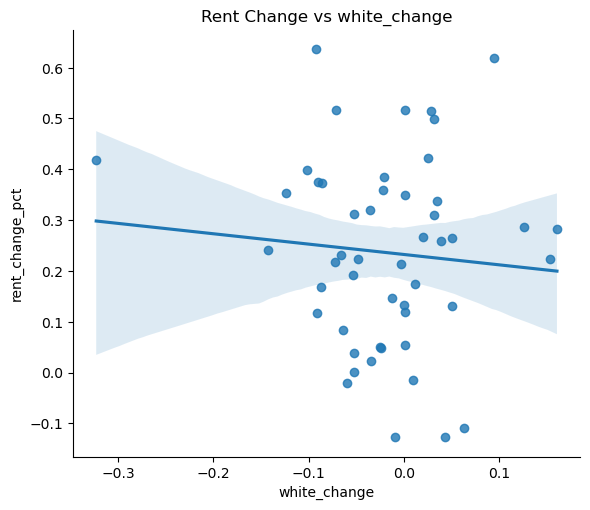

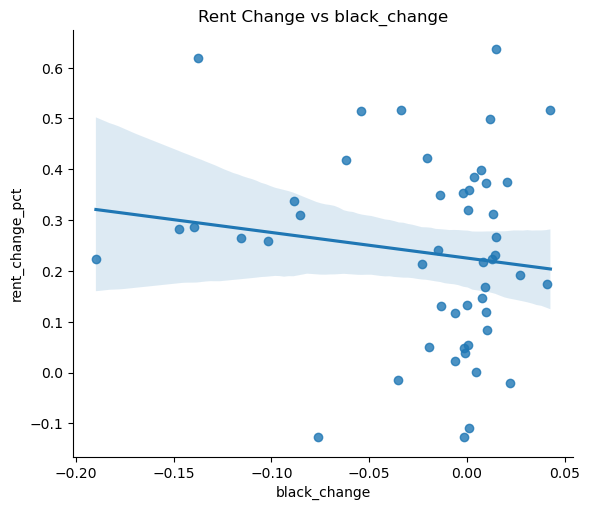

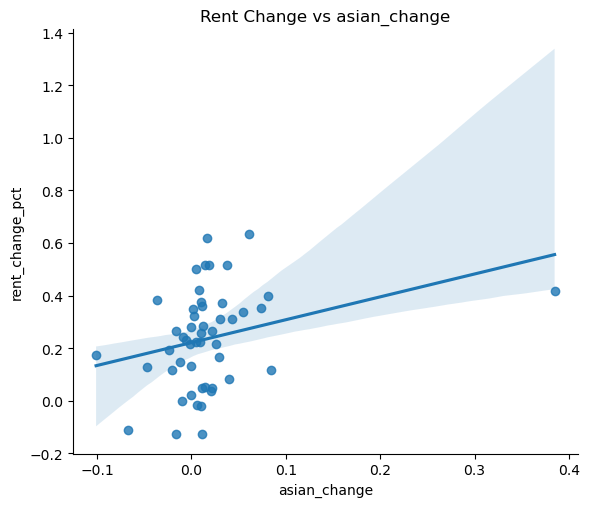

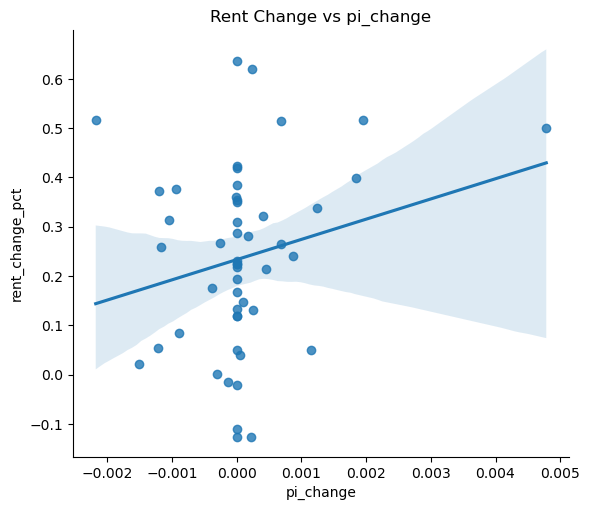

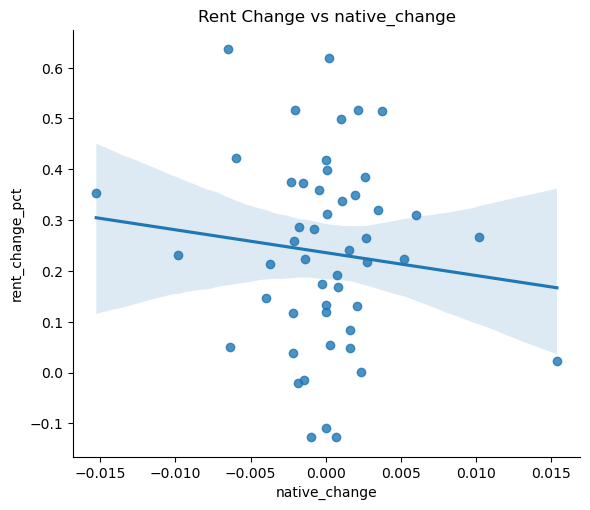

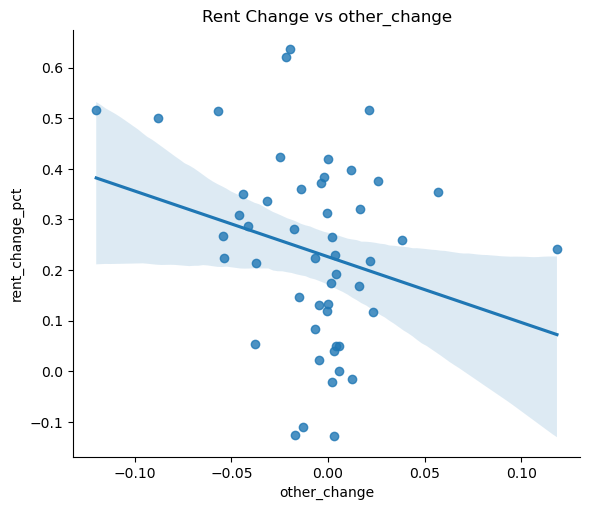

In [753]:
import seaborn as sns
import matplotlib.pyplot as plt

for race in ["white_change","black_change","asian_change","pi_change","native_change","other_change"]:
    sns.lmplot(data=final_wide, x=race, y="rent_change_pct", height=5, aspect=1.2)
    plt.title(f"Rent Change vs {race}")
    plt.show()


In [755]:
clean = final_wide[["rent_change_pct","white_change","black_change","asian_change",
                    "pi_change","native_change","other_change"]].replace([np.inf, -np.inf], np.nan).dropna()


In [756]:
import statsmodels.api as sm

X = clean[["white_change","black_change","asian_change","pi_change","native_change","other_change"]]
X = sm.add_constant(X)
y = clean["rent_change_pct"]

rlm_model = sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit()
print(rlm_model.summary())


                    Robust linear Model Regression Results                    
Dep. Variable:        rent_change_pct   No. Observations:                   50
Model:                            RLM   Df Residuals:                       43
Method:                          IRLS   Df Model:                            6
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Tue, 12 May 2026                                         
Time:                        12:47:23                                         
No. Iterations:                    33                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.1159      0.053      2.203

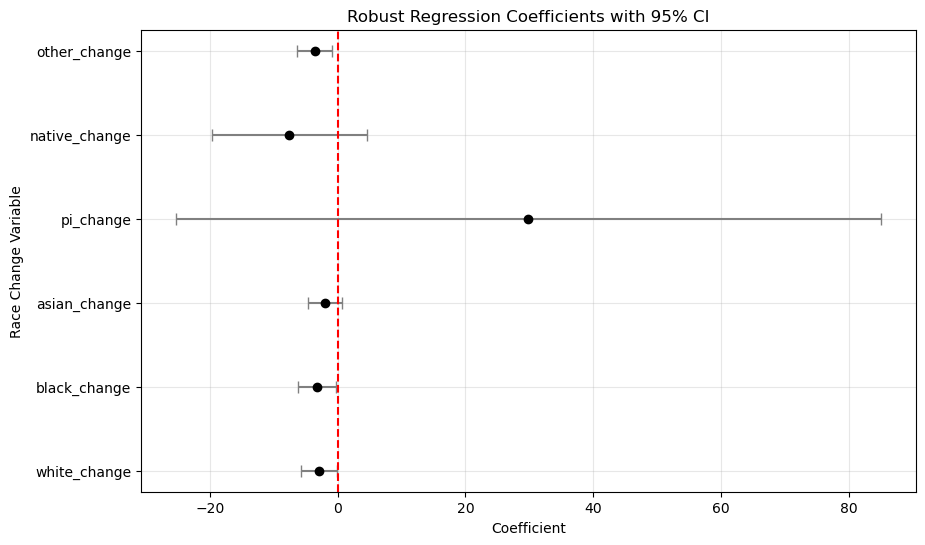

In [757]:
import matplotlib.pyplot as plt
import numpy as np

# Extract coefficients and standard errors
coef = rlm_model.params
se = rlm_model.bse

variables = coef.index[1:]  # skip constant
coef_vals = coef[1:]
se_vals = se[1:]

plt.figure(figsize=(10,6))
plt.errorbar(coef_vals, variables, xerr=1.96*se_vals, fmt='o', color='black',
             ecolor='gray', capsize=4)
plt.axvline(0, color='red', linestyle='--')
plt.title("Robust Regression Coefficients with 95% CI")
plt.xlabel("Coefficient")
plt.ylabel("Race Change Variable")
plt.grid(alpha=0.3)
plt.show()


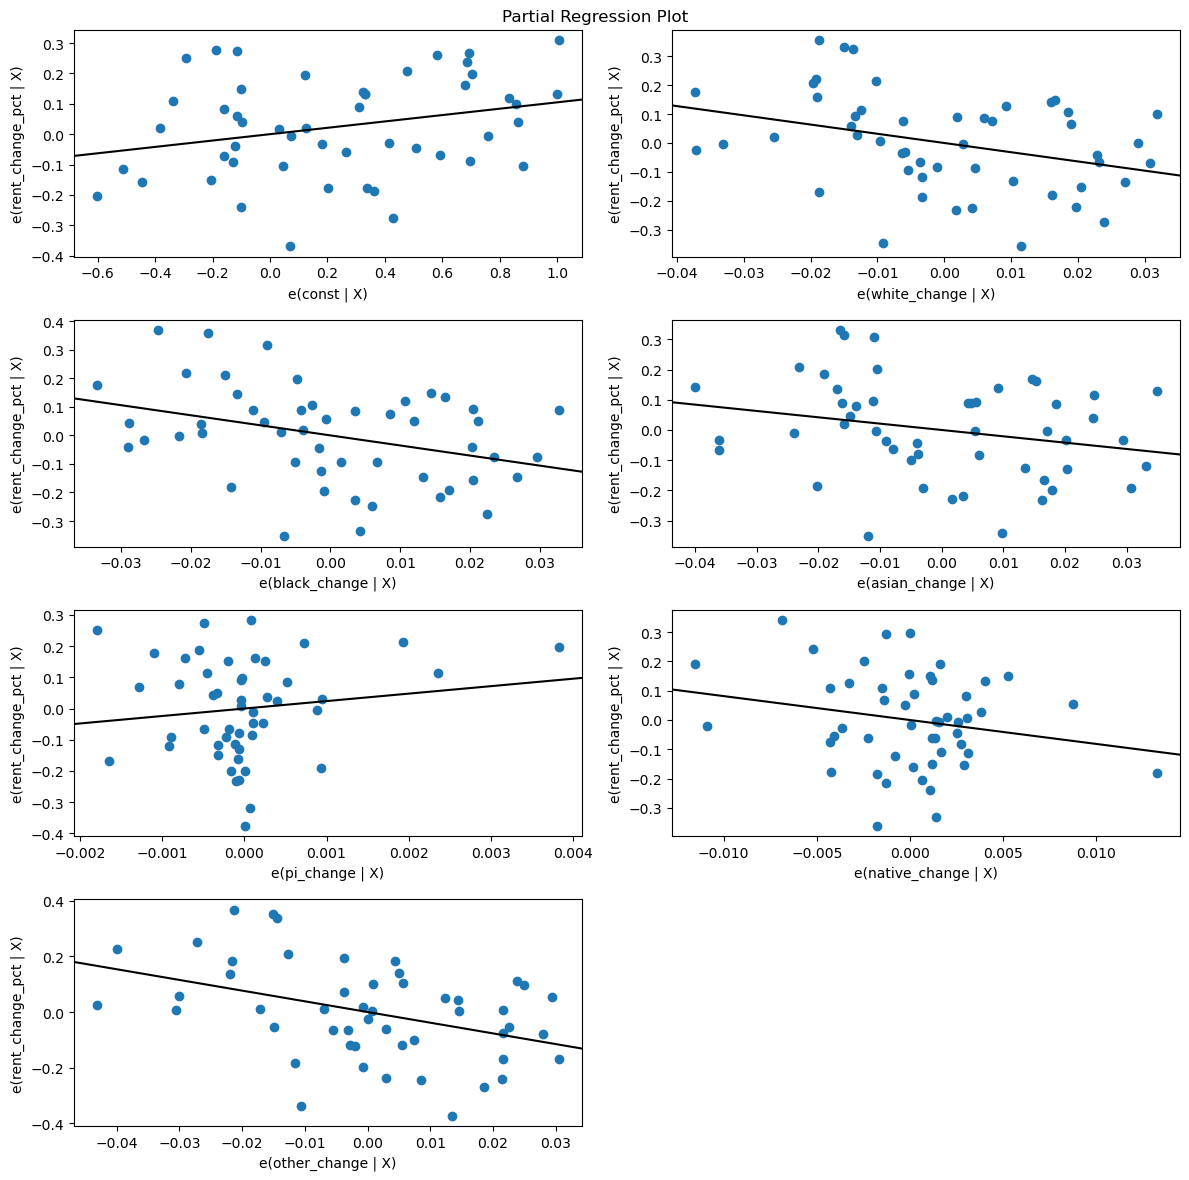

In [758]:
import statsmodels.api as sm

fig = plt.figure(figsize=(12, 12))
sm.graphics.plot_partregress_grid(rlm_model, fig=fig)
plt.tight_layout()
plt.show()


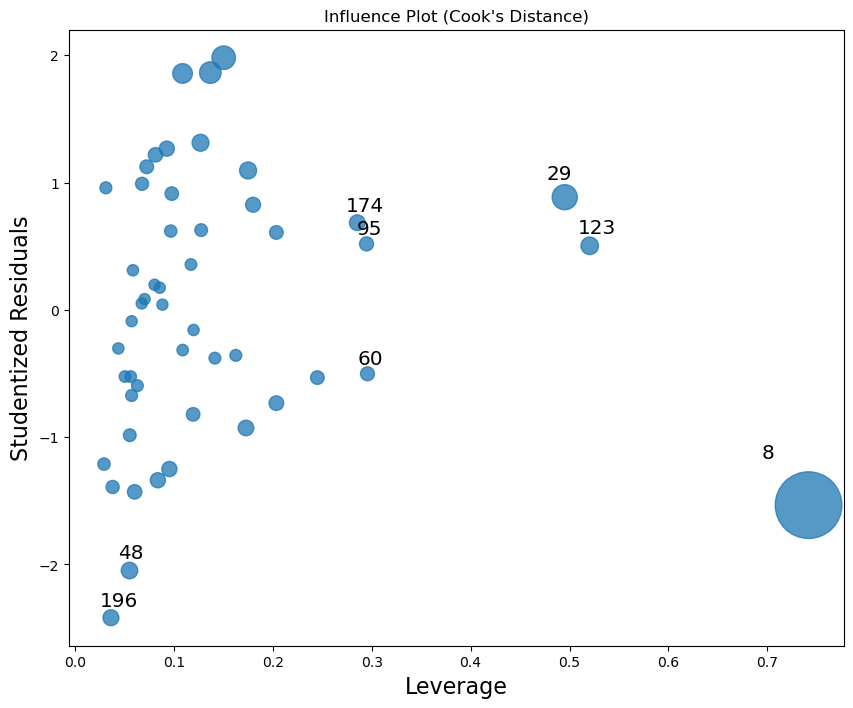

In [759]:
ols_model = sm.OLS(y, X).fit()
fig, ax = plt.subplots(figsize=(10, 8))
sm.graphics.influence_plot(ols_model, ax=ax, criterion="cooks")
plt.title("Influence Plot (Cook's Distance)")
plt.show()


In [760]:
race_cols = [
    "white_share_2020", "black_share_2020", "asian_share_2020",
    "pi_share_2020", "native_share_2020", "other_share_2020"
]

final_wide["largest_group_2020"] = final_wide[race_cols].idxmax(axis=1)


In [761]:
final_wide["largest_group_2020"] = (
    final_wide["largest_group_2020"]
    .str.replace("_share_2020", "")
)


C:\Users\sofie\AppData\Local\Temp\ipykernel_17768\3548995515.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


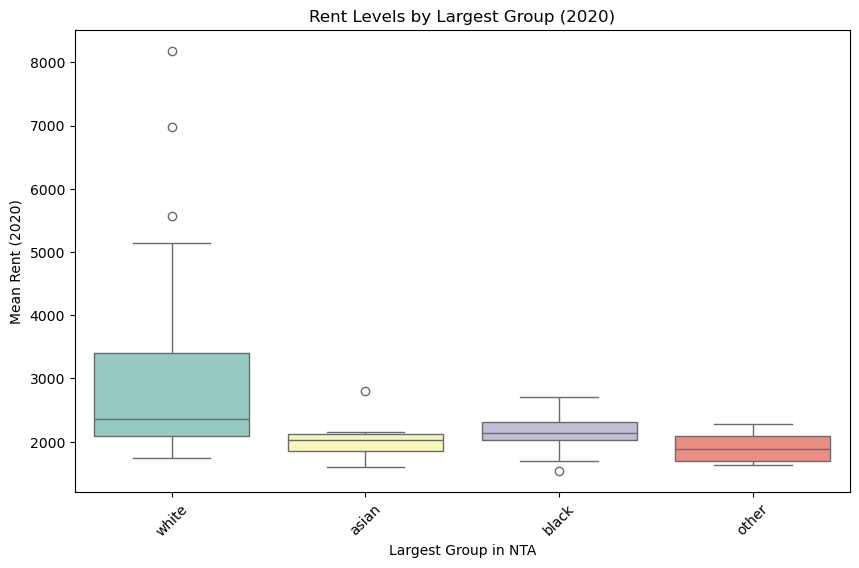

In [762]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(
    data=final_wide,
    x="largest_group_2020",
    y="rent_mean_nta_2020",
    palette="Set3"
)
plt.title("Rent Levels by Largest Group (2020)")
plt.xlabel("Largest Group in NTA")
plt.ylabel("Mean Rent (2020)")
plt.xticks(rotation=45)
plt.show()


In [764]:
import scipy.stats as stats

groups = [
    final_wide.loc[final_wide["largest_group_2020"] == race, "rent_mean_nta_2020"]
    for race in final_wide["largest_group_2020"].unique()
]

stats.f_oneway(*groups)


F_onewayResult(statistic=np.float64(nan), pvalue=np.float64(nan))

In [765]:
final_wide[[
    "rent_mean_nta_2020",
    "white_share_2020", "black_share_2020", "asian_share_2020",
    "pi_share_2020", "native_share_2020", "other_share_2020"
]].corr()["rent_mean_nta_2020"].sort_values(ascending=False)


rent_mean_nta_2020    1.000000
white_share_2020      0.527721
asian_share_2020     -0.038481
pi_share_2020        -0.132872
black_share_2020     -0.276010
native_share_2020    -0.291456
other_share_2020     -0.441676
Name: rent_mean_nta_2020, dtype: float64

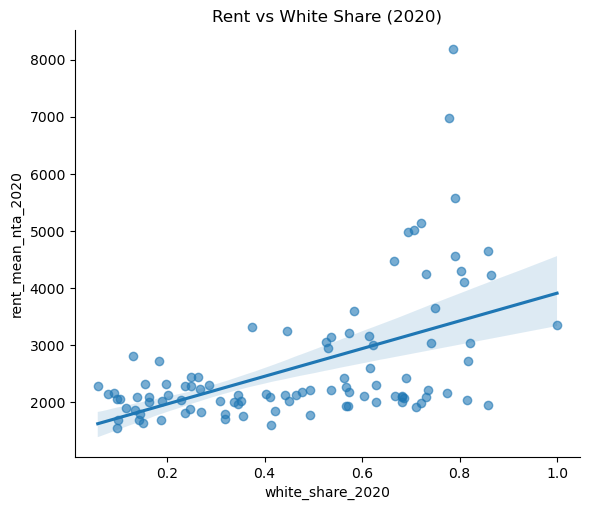

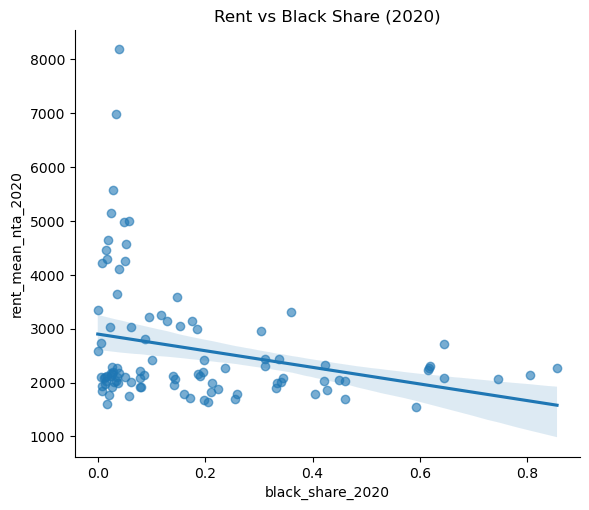

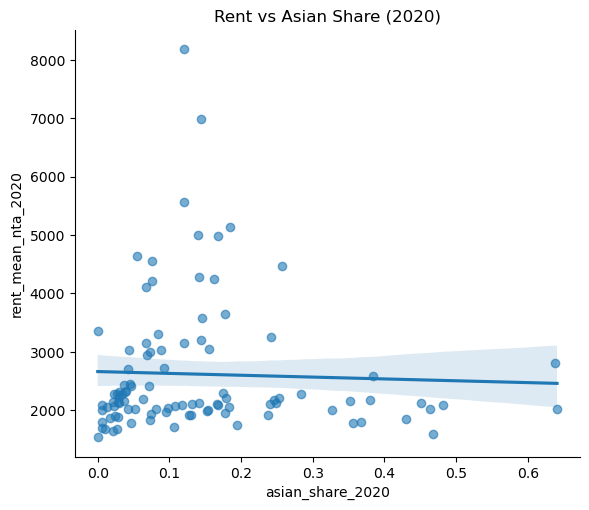

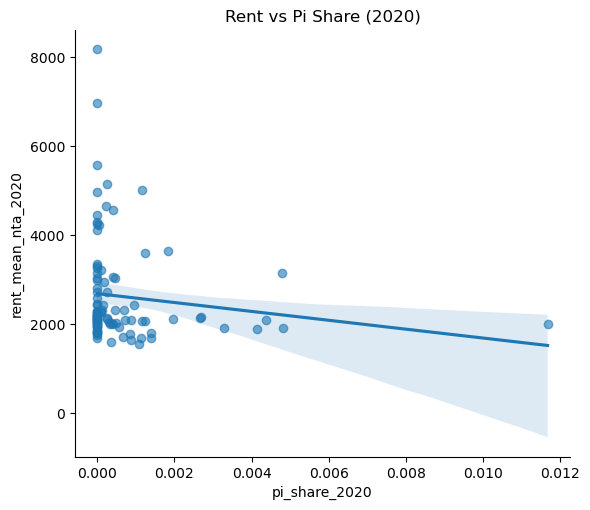

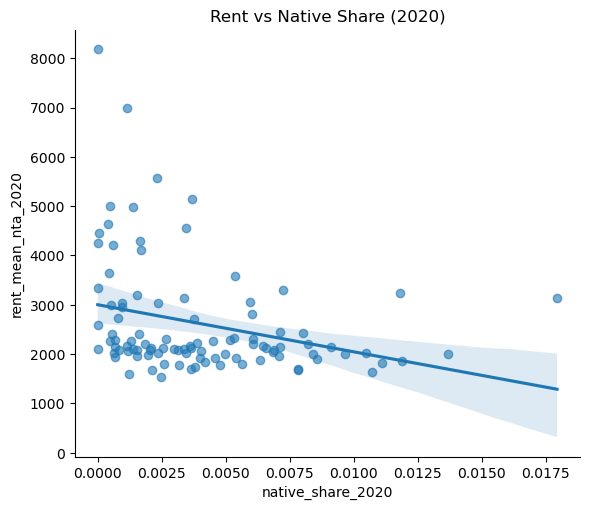

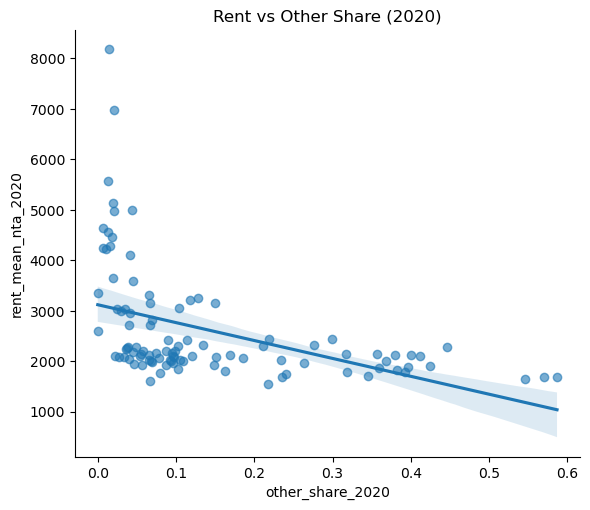

In [766]:
for race in ["white_share_2020","black_share_2020","asian_share_2020",
             "pi_share_2020","native_share_2020","other_share_2020"]:
    
    sns.lmplot(
        data=final_wide,
        x=race,
        y="rent_mean_nta_2020",
        height=5,
        aspect=1.2,
        scatter_kws={"alpha":0.6}
    )
    plt.title(f"Rent vs {race.replace('_share_2020','').title()} Share (2020)")
    plt.show()


In [768]:
import plotly.express as px
import numpy as np

race_vars = [
    "white_share_2020","black_share_2020","asian_share_2020",
    "pi_share_2020","native_share_2020","other_share_2020"
]

# Compute global y-axis range
y = final_wide["rent_mean_nta_2020"]
y_range = [y.min(), y.max()]

for race in race_vars:
    x = final_wide[race]
    y = final_wide["rent_mean_nta_2020"]

    fig = px.scatter(
        final_wide,
        x=race,
        y="rent_mean_nta_2020",
        hover_name="NTA_name",
        opacity=0.7,
        title=f"Rent vs {race.replace('_share_2020','').title()} Share (2020)",
        labels={
            race: race.replace("_share_2020", " share (%)").title(),
            "rent_mean_nta_2020": "Mean Rent (2020)"
        }
    )

    # Try to compute regression line safely
    try:
        # Only fit if x has variance and no NaN/inf
        if x.nunique() > 1 and x.notna().all() and y.notna().all():
            m, b = np.polyfit(x, y, 1)
            fig.add_scatter(
                x=x,
                y=m*x + b,
                mode="lines",
                name="Trend line",
                line=dict(color="red")
            )
    except Exception as e:
        print(f"Skipping regression for {race}: {e}")

    # Shared y-axis scale
    fig.update_yaxes(range=y_range)

    fig.update_layout(
        width=700,
        height=500,
        showlegend=False
    )

    fig.show()


In [777]:
# First, check current groups
print(type(groups), len(groups))

# Redefine groups as race categories
groups = ["white", "black", "asian", "native", "pi", "other"]

# Now run the plot code
plot_data = []

for idx, row in final.iterrows():
    for group in groups:
        plot_data.append({
            "NTA": row["NTA_name"],
            "year": str(row["year"]),
            "group": group,
            "share": row[f"{group}_share"]
        })

plot_df = pd.DataFrame(plot_data)

fig = px.bar(
    plot_df,
    x="NTA",
    y="share",
    color="group",
    barmode="stack",
    facet_col="year",
    category_orders={"group": groups},
    labels={"share": "Share of population", "NTA": "Neighborhood"},
    title="Racial distribution by neighborhood (2010 vs 2020)",
    height=600,
    width=1400
)

fig.show()

<class 'list'> 4


In [778]:
import plotly.graph_objects as go

# Prepare data - one row per NTA, with 2010/2020 shares and rent
heatmap_data = []

for idx, row in final[final["year"] == "2020"].iterrows():
    heatmap_data.append({
        "NTA": row["NTA_name"],
        "white_2020": row["white_share"],
        "black_2020": row["black_share"],
        "asian_2020": row["asian_share"],
        "other_2020": row["other_share"],
        "rent_2020": row["rent_mean_nta"],
        "boro": row["BoroName"]
    })

hm_df = pd.DataFrame(heatmap_data).dropna(subset=["rent_2020"]).sort_values("rent_2020", ascending=False)

# Create heatmap
fig = go.Figure()

races = ["white_2020", "black_2020", "asian_2020", "other_2020"]
race_labels = ["White", "Black", "Asian", "Other"]

fig.add_trace(go.Heatmap(
    z=[hm_df[race].values for race in races],
    x=hm_df["NTA"],
    y=race_labels,
    colorscale="YlOrRd",
    hovertemplate="<b>%{x}</b><br>%{y}: %{z:.1%}<extra></extra>"
))

fig.update_layout(
    title="Racial composition by neighborhood (sorted by 2020 rent)",
    height=600,
    width=1600,
    xaxis_title="Neighborhood",
    yaxis_title="Race",
    hovermode="closest"
)

fig.show()

# Show the data table sorted by rent
hm_df[["NTA", "rent_2020", "white_2020", "black_2020", "asian_2020", "other_2020", "boro"]].head(30)

,NTA,rent_2020,white_2020,black_2020,asian_2020,other_2020,boro
182,Tribeca-Civic Center,8178.906250,0.786793,0.038919,0.120408,0.014695,Manhattan
189,Upper West Side-Lincoln Square,6981.969840,0.777959,0.033913,0.144236,0.020669,Manhattan
84,Greenwich Village,5569.843750,0.791455,0.028411,0.119726,0.012568,Manhattan
64,Financial District-Battery Park City,5140.874774,0.720436,0.025278,0.185147,0.019155,Manhattan
32,Chelsea-Hudson Yards,5005.041667,0.706952,0.058420,0.139689,0.043655,Manhattan
117,Midtown South-Flatiron-Union Square,4977.456597,0.694879,0.048480,0.167872,0.020846,Manhattan
196,West Village,4648.104167,0.859308,0.018956,0.054502,0.006537,Manhattan
23,Brooklyn Heights,4561.979167,0.789897,0.052274,0.075647,0.013613,Brooklyn
160,SoHo-Little Italy-Hudson Square,4461.454545,0.666408,0.016233,0.257717,0.017737,Manhattan
55,East Midtown-Turtle Bay,4287.729167,0.802086,0.016752,0.141110,0.015308,Manhattan


In [779]:
# Get 2010 and 2020 data separately
data_2010 = final[final["year"] == "2010"][["NTA_name", "white_share", "black_share", "asian_share", "other_share"]].rename(columns={
    "white_share": "white_2010",
    "black_share": "black_2010", 
    "asian_share": "asian_2010",
    "other_share": "other_2010"
})

data_2020 = final[final["year"] == "2020"][["NTA_name", "white_share", "black_share", "asian_share", "other_share", "rent_mean_nta"]].rename(columns={
    "white_share": "white_2020",
    "black_share": "black_2020",
    "asian_share": "asian_2020", 
    "other_share": "other_2020"
})

# Merge and calculate changes
comparison = data_2010.merge(data_2020, on="NTA_name")

# Calculate percentage point changes in racial composition
comparison["white_change"] = (comparison["white_2020"] - comparison["white_2010"]) * 100
comparison["black_change"] = (comparison["black_2020"] - comparison["black_2010"]) * 100
comparison["asian_change"] = (comparison["asian_2020"] - comparison["asian_2010"]) * 100
comparison["other_change"] = (comparison["other_2020"] - comparison["other_2010"]) * 100

comparison = comparison.dropna(subset=["rent_mean_nta"]).sort_values("rent_mean_nta", ascending=False)

# Scatter: rent vs each race's change
fig = px.scatter(comparison, 
    x="rent_mean_nta", 
    y=["white_change", "black_change", "asian_change", "other_change"],
    hover_name="NTA_name",
    labels={"rent_mean_nta": "2020 Rent ($)", "value": "Change in % (2010-2020)"},
    title="Racial composition changes vs rent increase",
    height=600, width=1000
)

fig.show()

# Show neighborhoods with biggest demographic changes
comparison.nlargest(15, "rent_mean_nta")[["NTA_name", "rent_mean_nta", "white_change", "black_change", "asian_change", "other_change"]]

,NTA_name,rent_mean_nta,white_change,black_change,asian_change,other_change
182,Tribeca-Civic Center,8178.906250,0.106078,0.975878,-2.001270,-0.034376
189,Upper West Side-Lincoln Square,6981.969840,-5.204342,1.318493,4.306546,-0.026819
84,Greenwich Village,5569.843750,-6.400579,1.004618,3.995130,-0.662031
64,Financial District-Battery Park City,5140.874774,5.022244,-1.346172,-4.747311,-0.463198
32,Chelsea-Hudson Yards,5005.041667,-2.444921,-1.919320,2.240074,0.547797
117,Midtown South-Flatiron-Union Square,4977.456597,-6.010802,2.185590,1.060626,0.197695
196,West Village,4648.104167,-0.872928,-0.146397,-1.619995,-1.721435
23,Brooklyn Heights,4561.979167,-2.158444,0.123165,1.148890,-1.386483
160,SoHo-Little Italy-Hudson Square,4461.454545,6.373426,0.091015,-6.736750,-1.273793
55,East Midtown-Turtle Bay,4287.729167,-2.437152,-0.152562,1.125332,0.415989


In [781]:
final_wide.keys()

Index(['NTA_name', 'asian_share_2010', 'asian_share_2020', 'black_share_2010',
       'black_share_2020', 'native_share_2010', 'native_share_2020',
       'other_share_2010', 'other_share_2020', 'pi_share_2010',
       'pi_share_2020', 'rent_mean_nta_2010', 'rent_mean_nta_2020',
       'white_share_2010', 'white_share_2020', 'white_share_change',
       'black_share_change', 'asian_share_change', 'native_share_change',
       'pi_share_change', 'other_share_change', 'rent_change',
       'rent_change_pct', 'white_change', 'black_change', 'asian_change',
       'pi_change', 'native_change', 'other_change', 'largest_group_2020'],
      dtype='object')

In [783]:
# Top 10 by percent rent increase
top_10 = final_wide.dropna(subset=["rent_change_pct"]).nlargest(10, "rent_change_pct")

print(top_10[["NTA_name", "rent_mean_nta_2010", "rent_mean_nta_2020", "rent_change_pct", "white_change", "black_change", "asian_change", "other_change"]])

# Visualize
fig = go.Figure()

for race, color in [("white_change", "blue"), ("black_change", "orange"), ("asian_change", "green"), ("other_change", "red")]:
    fig.add_trace(go.Bar(x=top_10["NTA_name"], y=top_10[race], name=race.replace("_change", "").capitalize(), marker_color=color))

fig.update_layout(
    title="Racial composition changes in top 10 neighborhoods by % rent increase",
    xaxis_title="Neighborhood",
    yaxis_title="Change in % (2010-2020)",
    barmode="group",
    height=600,
    width=1400,
    hovermode="x unified"
)

fig.show()

                                         NTA_name  rent_mean_nta_2010  \
151                                     Rego Park         1328.125000   
14                      Bedford-Stuyvesant (East)         1672.500000   
95                                         Inwood         1393.772727   
39                                         Corona         1289.527027   
25                                Bushwick (East)         1606.750000   
29   Carroll Gardens-Cobble Hill-Gowanus-Red Hook         2097.625000   
202                   Windsor Terrace-South Slope         1914.285714   
8               Barren Island-Floyd Bennett Field         1825.000000   
186   Upper East Side-Lenox Hill-Roosevelt Island         2603.734375   
173                                     Sunnyside         1567.541667   

     rent_mean_nta_2020  rent_change_pct  white_change  black_change  \
151         2172.800000         0.635991     -0.092593      0.014704   
14          2709.421875         0.619983      0.0952

In [784]:
# Top 10 most expensive in 2020
top_10_expensive = final_wide.dropna(subset=["rent_mean_nta_2020"]).nlargest(10, "rent_mean_nta_2020")

print(top_10_expensive[["NTA_name", "rent_mean_nta_2020", "white_share_2020", "black_share_2020", "asian_share_2020", "other_share_2020"]])

# Stacked bar showing 2020 racial composition
fig = go.Figure()

for race, color in [("white_share_2020", "blue"), ("black_share_2020", "orange"), ("asian_share_2020", "green"), ("other_share_2020", "red")]:
    fig.add_trace(go.Bar(
        x=top_10_expensive["NTA_name"],
        y=top_10_expensive[race] * 100,
        name=race.replace("_share_2020", "").capitalize(),
        marker_color=color
    ))

fig.update_layout(
    title="Racial composition in top 10 most expensive neighborhoods (2020)",
    xaxis_title="Neighborhood",
    yaxis_title="% of population",
    barmode="stack",
    height=600,
    width=1400,
    hovermode="x unified"
)

fig.show()

                                 NTA_name  rent_mean_nta_2020  \
182                  Tribeca-Civic Center         8178.906250   
189        Upper West Side-Lincoln Square         6981.969840   
84                      Greenwich Village         5569.843750   
64   Financial District-Battery Park City         5140.874774   
32                   Chelsea-Hudson Yards         5005.041667   
117   Midtown South-Flatiron-Union Square         4977.456597   
196                          West Village         4648.104167   
23                       Brooklyn Heights         4561.979167   
160       SoHo-Little Italy-Hudson Square         4461.454545   
55                East Midtown-Turtle Bay         4287.729167   

     white_share_2020  black_share_2020  asian_share_2020  other_share_2020  
182          0.786793          0.038919          0.120408          0.014695  
189          0.777959          0.033913          0.144236          0.020669  
84           0.791455          0.028411          0

In [785]:
# Calculate overall NYC racial distribution in 2020
nyc_2020 = final[final["year"] == "2020"]
nyc_overall = {
    "white": nyc_2020["white_share"].mean(),
    "black": nyc_2020["black_share"].mean(),
    "asian": nyc_2020["asian_share"].mean(),
    "other": nyc_2020["other_share"].mean()
}

# Add NYC overall as a row
top_10_with_nyc = top_10_expensive.copy()
top_10_with_nyc = pd.concat([
    top_10_with_nyc,
    pd.DataFrame([{
        "NTA_name": "NYC Overall",
        "white_share_2020": nyc_overall["white"],
        "black_share_2020": nyc_overall["black"],
        "asian_share_2020": nyc_overall["asian"],
        "other_share_2020": nyc_overall["other"]
    }])
], ignore_index=True)

# Stacked bar comparison
fig = go.Figure()

for race, color in [("white_share_2020", "blue"), ("black_share_2020", "orange"), ("asian_share_2020", "green"), ("other_share_2020", "red")]:
    fig.add_trace(go.Bar(
        x=top_10_with_nyc["NTA_name"],
        y=top_10_with_nyc[race] * 100,
        name=race.replace("_share_2020", "").capitalize(),
        marker_color=color
    ))

fig.update_layout(
    title="Racial composition: top 10 most expensive vs NYC overall (2020)",
    xaxis_title="Neighborhood",
    yaxis_title="% of population",
    barmode="stack",
    height=600,
    width=1400,
    hovermode="x unified"
)

fig.show()

print(f"NYC Overall 2020: White {nyc_overall['white']:.1%}, Black {nyc_overall['black']:.1%}, Asian {nyc_overall['asian']:.1%}, Other {nyc_overall['other']:.1%}")

NYC Overall 2020: White 42.6%, Black 23.1%, Asian 14.7%, Other 13.6%


In [786]:
# Top 10 cheapest in 2020
top_10_cheapest = final_wide.dropna(subset=["rent_mean_nta_2020"]).nsmallest(10, "rent_mean_nta_2020")

# Add NYC overall for comparison
top_10_cheap_with_nyc = pd.concat([
    top_10_cheapest,
    pd.DataFrame([{
        "NTA_name": "NYC Overall",
        "white_share_2020": nyc_overall["white"],
        "black_share_2020": nyc_overall["black"],
        "asian_share_2020": nyc_overall["asian"],
        "other_share_2020": nyc_overall["other"]
    }])
], ignore_index=True)

print(top_10_cheapest[["NTA_name", "rent_mean_nta_2020", "white_share_2020", "black_share_2020", "asian_share_2020", "other_share_2020"]])

# Stacked bar comparison
fig = go.Figure()

for race, color in [("white_share_2020", "blue"), ("black_share_2020", "orange"), ("asian_share_2020", "green"), ("other_share_2020", "red")]:
    fig.add_trace(go.Bar(
        x=top_10_cheap_with_nyc["NTA_name"],
        y=top_10_cheap_with_nyc[race] * 100,
        name=race.replace("_share_2020", "").capitalize(),
        marker_color=color
    ))

fig.update_layout(
    title="Racial composition: top 10 cheapest vs NYC overall (2020)",
    xaxis_title="Neighborhood",
    yaxis_title="% of population",
    barmode="stack",
    height=600,
    width=1400,
    hovermode="x unified"
)

fig.show()

                               NTA_name  rent_mean_nta_2020  white_share_2020  \
34   Claremont Village-Claremont (East)         1537.500000          0.096807   
6                            Auburndale         1600.000000          0.412231   
183  University Heights (North)-Fordham         1637.000000          0.151542   
13                         Bedford Park         1677.500000          0.141557   
69                      Fordham Heights         1685.772727          0.098710   
181                             Tremont         1688.428571          0.186893   
131                             Norwood         1704.642857          0.318198   
203                           Woodhaven         1746.500000          0.354764   
9                            Bath Beach         1773.350000          0.492572   
0                              Allerton         1786.875000          0.319606   

     black_share_2020  asian_share_2020  other_share_2020  
34           0.592613          0.001008         

In [915]:
from plotly.subplots import make_subplots

# Get top and bottom 10 for 2020
top_10_2020 = final_wide.dropna(subset=["rent_mean_nta_2020"]).nlargest(10, "rent_mean_nta_2020")
bottom_10_2020 = final_wide.dropna(subset=["rent_mean_nta_2020"]).nsmallest(10, "rent_mean_nta_2020")

# Add NYC overall to each
nyc_row = pd.DataFrame([{
    "NTA_name": "NYC Overall",
    "white_share_2020": nyc_overall["white"],
    "black_share_2020": nyc_overall["black"],
    "asian_share_2020": nyc_overall["asian"],
    "other_share_2020": nyc_overall["other"],
    "rent_change_pct": 0,
    "white_change": 0,
    "black_change": 0,
    "asian_change": 0,
    "other_change": 0
}])

top_10_with_nyc = pd.concat([top_10_2020, nyc_row], ignore_index=True)
bottom_10_with_nyc = pd.concat([bottom_10_2020, nyc_row], ignore_index=True)

# Color palette for races
colors = {
    "white": "#2e4460",      # Oxford Blue
    "black": "#cc5e42",      # Terracotta
    "asian": "#7a8c5c",      # Olive
    "other": "#c8a96e"       # Sand
}

# Create subplots
fig = make_subplots(
    rows=2, cols=1,
    specs=[[{"type": "bar"}], [{"type": "bar"}]],
    subplot_titles=("Most Expensive Areas", "Cheapest Areas")
)

# Left: Top 10
for race, color in [("white_share_2020", colors["white"]), 
                     ("black_share_2020", colors["black"]), 
                     ("asian_share_2020", colors["asian"]), 
                     ("other_share_2020", colors["other"])]:
    fig.add_trace(
        go.Bar(
            x=top_10_with_nyc["NTA_name"],
            y=top_10_with_nyc[race] * 100,
            name=race.replace("_share_2020", "").capitalize(),
            marker_color=color,
            showlegend=True,
            hovertemplate="%{y:.2f}%<extra></extra>"
        ),
        row=1, col=1
    )

# Right: Bottom 10
for race, color in [("white_share_2020", colors["white"]), 
                     ("black_share_2020", colors["black"]), 
                     ("asian_share_2020", colors["asian"]), 
                     ("other_share_2020", colors["other"])]:
    fig.add_trace(
        go.Bar(
            x=bottom_10_with_nyc["NTA_name"],
            y=bottom_10_with_nyc[race] * 100,
            name=race.replace("_share_2020", "").capitalize(),
            marker_color=color,
            showlegend=False,
            hovertemplate="%{y:.2f}%<extra></extra>"
        ),
        row=2, col=1
    )

# Add annotations to left
# for idx, row in top_10_with_nyc.iterrows():

#     fig.add_annotation(
#         x=row["NTA_name"],
#         y=110,
#         showarrow=False,
#         font=dict(size=8),
#         bgcolor="#ecddd0",
#         bordercolor="#8b5e3c",
#         borderwidth=1,
#         row=1, col=1
#     )

# # Add annotations to right
# for idx, row in bottom_10_with_nyc.iterrows():
#     fig.add_annotation(
#         x=row["NTA_name"],
#         y=110,
#         showarrow=False,
#         font=dict(size=8),
#         bgcolor="#ecddd0",
#         bordercolor="#8b5e3c",
#         borderwidth=1,
#         row=2, col=1
#     )


fig.update_xaxes(title_text="Neighborhood", row=2, col=1)
fig.update_yaxes(gridcolor="#c4b8a8", zerolinecolor="#c4b8a8")
# fig.update_yaxes(title_text="% of population (2020)", row=1, col=1)
# fig.update_yaxes(title_text="% of population (2020)", row=2, col=1)

fig.update_layout(
    title={'text':"10 Most Expensive and Cheapest Neighborhoods",
           'y':0.99,
            'x':0.5,
           'xanchor': 'center',
            'yanchor': 'top'},
    height=710,
    width=550,
    barmode="stack",
    paper_bgcolor="#ede6dc",
    plot_bgcolor="#f5f4f2",
    font=dict(color="#2e2a24", family="Arial"),
    hovermode="x unified",
    margin={'t':50,'b':50,'l':50,'r':30},
)
# Remove yaxis_title from update_layout, then add this after the layout update:
fig.add_annotation(
    text="% of population (2020)",
    xref="paper", yref="paper",
    x=-0.12,
    y=0.45,  # Adjust y to move up/down
    showarrow=False,
    textangle=-90,
    font=dict(size=12, color="#2e2a24")
)

fig.write_html('visualizations/rent_vs_ethnicity.html', include_plotlyjs='cdn')
fig.show()

# Making area_to_nta

In [534]:
import pandas as pd
import re

# -----------------------------
# 1. Load your NTA lookup
# -----------------------------
nta_df = pd.read_excel("data/nyc2020census_tract_nta_cdta_relationships.xlsx")  # replace with your file


In [536]:
nta_df = nta_df[["GEOID", "BoroName", "CT2020", "NTACode", "NTAName", "CDTACode", "CDTAName"]].dropna()

In [537]:
# collapse duplicates using MOST COMMON NTA code
nta_clean = (
    nta_df.groupby("NTAName")[["GEOID", "BoroName", "CT2020", "NTACode", "CDTACode", "CDTAName"]]
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index()
)


In [546]:
nta_clean.head(2)

,NTA_name,GEOID,BoroName,tract,NTA,CDTACode,CDTAName
0,Allerton,36005032400,Bronx,32400,BX1104,BX11,BX11 Pelham Parkway-Morris Park (CD 11 Approxi...
1,Alley Pond Park,36081138502,Queens,138502,QN1191,QN11,QN11 Auburndale-Bayside-Douglaston (CD 11 Appr...


In [538]:
nta_clean = nta_clean.rename(columns={
    "CountyFIPS": "county",
    "CT2020": "tract",
    "NTACode": "NTA",
    "NTAName": "NTA_name"
})

In [549]:

# -----------------------------
# 2. Build borough → NTA_name lists
# -----------------------------
nta_by_boro = {
    "BRONX": nta_clean[nta_clean["NTA"].str.startswith("BX")],
    "BROOKLYN": nta_clean[nta_clean["NTA"].str.startswith("BK")],
    "MANHATTAN": nta_clean[nta_clean["NTA"].str.startswith("MN")],
    "QUEENS": nta_clean[nta_clean["NTA"].str.startswith("QN")],
    "STATEN ISLAND": nta_clean[nta_clean["NTA"].str.startswith("SI")],
}

# -----------------------------
# 3. Representative NTA overrides
# -----------------------------
representative = {
    # Manhattan aggregates
    "All Downtown": "Battery Park City-Lower Manhattan",
    "All Midtown": "Midtown-Midtown South",
    "All Upper East Side": "Upper East Side-Carnegie Hill",
    "All Upper West Side": "Upper West Side-Lincoln Square",
    "All Upper Manhattan": "Harlem (North)",
    "Manhattan": "Midtown-Midtown South",
    "NYC": "Midtown-Midtown South",

    # Brooklyn aggregates
    "North Brooklyn": "North Side-South Side",
    "South Brooklyn": "Sunset Park (Central)",
    "East Brooklyn": "East New York",
    "Northwest Brooklyn": "Downtown Brooklyn-DUMBO-Boerum Hill",
    "Brooklyn": "Downtown Brooklyn-DUMBO-Boerum Hill",

    # Queens aggregates
    "Central Queens": "Forest Hills",
    "Northwest Queens": "Astoria (Central)",
    "Northeast Queens": "Bayside-Bayside Hills",
    "Rockaway All": "Far Rockaway-Bayswater",
    "The Rockaways": "Rockaway Beach-Arverne-Edgemere",
    "Queens": "Flushing",

    # Bronx aggregates
    "Bronx": "Mott Haven-Port Morris",

    # Staten Island aggregates
    "Staten Island": "St. George-New Brighton",
}

# -----------------------------
# 4. Park → residential mapping
# -----------------------------
park_to_residential = {
    "Prospect Park": "Park Slope-Gowanus",
    "Prospect Park South": "Park Slope-Gowanus",
    "Central Park South": "Upper West Side-Lincoln Square",
    "Forest Park": "Woodhaven",
    "Van Cortlandt Park": "North Riverdale-Fieldston-Riverdale",
}

# -----------------------------
# 5. Keyword-based matcher
# -----------------------------
def keyword_match(area, borough):
    words = re.findall(r"[A-Za-z]+", area.lower())
    candidates = nta_by_boro[borough]

    scores = []
    for _, row in candidates.iterrows():
        nta = row["NTA_name"].lower()
        score = sum(w in nta for w in words)
        scores.append((row["NTA_name"], score))

    best = max(scores, key=lambda x: x[1])
    return best[0]



In [550]:
# -----------------------------
# 6. Build mapping
# -----------------------------
rows = []

for _, row in rent_yearly.iterrows():
    area = row["areaName"]
    boro = row["Borough"]

    # override: aggregates
    if area in representative:
        nta_name = representative[area]

    # override: parks
    elif area in park_to_residential:
        nta_name = park_to_residential[area]

    # normal keyword match
    else:
        nta_name = keyword_match(area, boro)

    rows.append([area, boro, nta_name])

area_to_nta = pd.DataFrame(rows, columns=["areaName", "Borough", "NTA_name"])

# merge NTA codes from nta_clean
area_to_nta = area_to_nta.merge(nta_clean, on="NTA_name", how="left")



In [551]:
area_to_nta.head()

,areaName,Borough,NTA_name,GEOID,BoroName,tract,NTA,CDTACode,CDTAName
0,Baychester,BRONX,Eastchester-Edenwald-Baychester,3.600504e+10,Bronx,35600.0,BX1202,BX12,BX12 Wakefield-Williamsbridge-Eastchester (CD ...
1,Baychester,BRONX,Eastchester-Edenwald-Baychester,3.600504e+10,Bronx,35600.0,BX1202,BX12,BX12 Wakefield-Williamsbridge-Eastchester (CD ...
2,Baychester,BRONX,Eastchester-Edenwald-Baychester,3.600504e+10,Bronx,35600.0,BX1202,BX12,BX12 Wakefield-Williamsbridge-Eastchester (CD ...
3,Baychester,BRONX,Eastchester-Edenwald-Baychester,3.600504e+10,Bronx,35600.0,BX1202,BX12,BX12 Wakefield-Williamsbridge-Eastchester (CD ...
4,Baychester,BRONX,Eastchester-Edenwald-Baychester,3.600504e+10,Bronx,35600.0,BX1202,BX12,BX12 Wakefield-Williamsbridge-Eastchester (CD ...


In [552]:

# drop duplicates
area_to_nta = area_to_nta.drop_duplicates()

# sort by Borough then areaName
area_to_nta = area_to_nta.sort_values(["Borough", "areaName"])



In [553]:
area_to_nta.to_csv("area_to_nta.csv", index=False)